# Homework 03: Learning Curves and Training Workflow

#### Due Date: Sunday, September 20th at 11:59pm (with 2 hour plus 1 minute grace period)

#### The late policy is described in the DX 703 Syllabus. 

In this assignment, you will learn how to design, train, and evaluate neural networks by systematically exploring key design choices. Your focus will be on developing an effective **training workflow** — using learning curves and validation metrics to guide your decisions.

We'll again use the **Forest Cover Type (Covertype) dataset,** which has ~581k tabular records with 54 cartographic/topographic features (elevation, aspect, slope, soil and wilderness indicators) used to predict one of seven tree cover types in Colorado’s Roosevelt National Forest. 

We will start with a **baseline model** (two hidden layers of sizes 64 and 32), and gradually introduce and tune different hyperparameters. Each of the first five problems considers  different hyperparameter choices, and the last problem is your chance to use what you have learned to design your best model:

1. **Activation function** – Compare ReLU, sigmoid, and tanh to see which provides the best accuracy.
2. **Learning rate** – Explore a range of learning rates and identify which balances convergence speed and stability.
3. **Dropout** – Investigate how different dropout rates reduce overfitting and where they are most effective.
4. **L2 regularization** – Experiment with weight penalties to encourage simpler models and avoid memorization.
5. **Dropout + L2** – Combine both regularization techniques and study their interaction.
6. **Best model design** – Use all your insights to build and train your strongest model, with the option to try **learning rate scheduling** for further improvement.

In this homework, you will use **early stopping** to select the "best" model at the epoch of **minimum validation loss**, and you will report the **validation accuracy** of that selected model as the primary measure of performance. Test accuracy is reported for reference but is not used for model selection.

> **Note:** Throughout this homework, best always refers to the model selected by early stopping at the epoch of minimum validation loss. Do not report metrics from the final training epoch unless explicitly instructed.

By the end of this homework, you will not only understand how different hyperparameters affect training and generalization, but also gain hands-on practice in building a disciplined workflow for model development.

There are 10 graded problems, worth 8 points each, with 5 points for free if you complete the homework. 

In [1]:
# Useful imports

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import time
import os

from sklearn.model_selection import train_test_split, StratifiedShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.utils import class_weight

import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Input,Dropout
from tensorflow.keras.optimizers import Adam

from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers.schedules import ExponentialDecay


from tensorflow.keras.datasets import fashion_mnist

# utility code

random_seed = 42

def format_hms(seconds):
    return time.strftime("%H:%M:%S", time.gmtime(seconds))

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'  # Suppresses INFO and WARNING messages


In [2]:
# Utility function to plot learning curves and keep track of all results

# Call `print_results()` to see listing of all results logged so far


def plot_learning_curves(hist, title, verbose=True):
    
    val_losses = hist.history['val_loss']
    min_val_loss = min(val_losses)
    min_val_epoch = val_losses.index(min_val_loss)
    val_acc_at_min_loss = hist.history['val_accuracy'][min_val_epoch]

    epochs = range(1, len(val_losses) + 1)  # epoch numbers starting at 1

    fig, axs = plt.subplots(2, 1, figsize=(8, 8), sharex=True)

    # --- Loss Plot ---
    axs[0].plot(epochs, hist.history['loss'], label='train loss')
    axs[0].plot(epochs, hist.history['val_loss'], label='val loss')
    axs[0].scatter(min_val_epoch + 1, min_val_loss, color='red', marker='x', s=50, label='min val loss')
    axs[0].set_title(f'{title} - Categorical Cross-Entropy Loss')
    axs[0].set_ylabel('Loss')
    axs[0].legend()
    axs[0].grid(True)

    # --- Accuracy Plot ---
    axs[1].plot(epochs, hist.history['accuracy'], label='train acc')
    axs[1].plot(epochs, hist.history['val_accuracy'], label='val acc')
    axs[1].scatter(min_val_epoch + 1, val_acc_at_min_loss, color='red', marker='x', s=50, label='acc @ min val loss')
    axs[1].set_title(f'{title} - Accuracy')
    axs[1].set_xlabel('Epoch')
    axs[1].set_ylabel('Accuracy')
    axs[1].legend()
    axs[1].grid(True)
    axs[1].set_ylim(0, 1.05)

    plt.tight_layout()
    plt.show()

    if verbose:
        print(f"Final Training Loss:            {hist.history['loss'][-1]:.4f}")
        print(f"Final Training Accuracy:        {hist.history['accuracy'][-1]:.4f}")
        print(f"Final Validation Loss:          {hist.history['val_loss'][-1]:.4f}")
        print(f"Final Validation Accuracy:      {hist.history['val_accuracy'][-1]:.4f}")
        print(f"Minimum Validation Loss:        {min_val_loss:.4f} (Epoch {min_val_epoch + 1})")
        print(f"Validation Accuracy @ Min Loss: {val_acc_at_min_loss:.4f}")

    results[title] = (val_acc_at_min_loss,min_val_epoch + 1)

results = {}

**The plotting function will record the validation accuracy for each experiment, using the plot title as key. The next function will print these out (see the last cell in the notebook).**


In order to see all results, you must give a different plot title to each experiment.

In [3]:
def print_results():
    for title, (acc, ep) in sorted(results.items(), 
                                   key=lambda kv: kv[1][0],   # kv[1] is (acc, epoch); [0] is acc
                                   reverse=True
                                  ):
        print(f"{title:<40}\t{acc:.4f}")

### Wrapper to train, display results, and run test set

We assume multi-class classification, and allow setting various parameters for training. 

In [4]:
# Uses globals X_train,y_train,X_val,y_val

def train_and_test(model, 
                   epochs        = 500,                   # Just needs to be bigger than early stop point
                   lr_schedule   = 0.001,                 # Adam default / 10 seems to work well for this dataset
                   optimizer     = "Adam",
                   title         = "Learning Curves",
                   batch_size    = 64,                     # experiments confirmed this was optimal with other parameters at default
                   use_early_stopping = True,
                   patience      = 10,                                       
                   min_delta     = 0.0001,                 
                   callbacks     = [],                     # for extra callbacks other than early stopping
                   verbose       = 0,
                   return_history = False
                  ):

    print(f"\n{title}\n")


    if optimizer == "Adam":
        opt = Adam(learning_rate=lr_schedule) 
    else:
        opt = optimizer
    
    #Compiling the model
    model.compile(optimizer=opt, 
                  loss="sparse_categorical_crossentropy", 
                  metrics=["accuracy"]
                 )

    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=patience,
        min_delta=min_delta,
        restore_best_weights=True,               # this will mean that the model which produced the smallest validation loss will be returned
        verbose=verbose
    )
    

    if use_early_stopping:
        cbs=[early_stop] + callbacks
    else:
        cbs=callbacks

    # start timer
    start = time.time()
    
    # Fit the model with early stopping
    history = model.fit(X_train, y_train,
                        epochs=epochs,
                        batch_size=batch_size,
                        validation_data=(X_val, y_val),       # must use stratified validation set
                        callbacks=cbs,
                        verbose=verbose
                       )

    if use_early_stopping:
        best_epoch = early_stop.best_epoch
        best_acc   = history.history['val_accuracy'][best_epoch]
    else:
        best_epoch = np.argmax(history.history['val_accuracy'])
        best_acc   = history.history['val_accuracy'][best_epoch]
    
    # Plot training history
    plot_learning_curves(history, title=title)

    # Evaluate on test data
    test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
    
    print(f"\nTest Loss: {test_loss:.4f}")
    print(f"Test Accuracy: {test_accuracy:.4f}")

    print(f"\nValidation-Test Gap (accuracy): {abs(best_acc - test_accuracy):.6f}")
    
    # Record end time and print execution time
    end = time.time()
    print(f"\nExecution Time: " + format_hms(end-start))

    if return_history:
        return history

### Load the dataset and extract a stratified subset

This data set is rather large (581,012 samples) and unbalanced, but for the purposes of this homework, we use a much smaller set, and select samples so that it is balanced. 

In [5]:
# complete cell: load, balance, split into X_train/y_train/x_val/y_val/X_test/y_test, and standardize
from collections import Counter
from sklearn.datasets import fetch_covtype
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np

# 1) load
x, y = fetch_covtype(return_X_y=True)  # y in {1..7}
print("full dataset shape:", x.shape)

# 2) build a perfectly balanced subset across 7 classes (no replacement)
classes, counts = np.unique(y, return_counts=True)
# min_count = counts.min()  # size of rarest class                         # You can modify this parameter to increase the size of the dataset, but above
min_count = 1000                                                           # counts.min() you'll produce an unbalanced set. 


rng = np.random.default_rng(42)

idx_list = []
for c in classes:
    c_idx = np.where(y == c)[0]
    chosen = rng.choice(c_idx, size=min_count, replace=False)
    idx_list.append(chosen)

idx_bal = np.concatenate(idx_list)
rng.shuffle(idx_bal)

X_sub = x[idx_bal]
y_sub = y[idx_bal] - 1  # relabel to {0..6} for keras
print("balanced subset shape:", X_sub.shape, "class counts:", dict(Counter(y_sub)))

# 3) stratified 60/20/20 split (train/val/test)
test_size = 0.20
val_size = 0.20  # of the whole dataset

X_trainval, X_test, y_trainval, y_test = train_test_split(
    X_sub, y_sub, test_size=test_size, random_state=random_seed, stratify=y_sub
)
val_size_rel = val_size / (1.0 - test_size)  # e.g., 0.20 / 0.80 = 0.25

X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=val_size_rel, random_state=random_seed, stratify=y_trainval
)

# 4) standardize using train-only stats (float32 for tensorflow friendliness)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train).astype(np.float32)
X_val   = scaler.transform(X_val).astype(np.float32)
X_test  = scaler.transform(X_test).astype(np.float32)

# 5) quick sanity checks
def show_counts(name, y_arr):
    c = Counter(y_arr)
    total = sum(c.values())
    print(f"{name}: total={total}, per-class={dict(c)}")

print("shapes:", "X_train", X_train.shape, "X_val", X_val.shape, "X_test", X_test.shape)
show_counts("train", y_train)
show_counts("val  ", y_val)
show_counts("test ", y_test)

# you now have: X_train, y_train, X_val, y_val, X_test, y_test

# Looks like integer encoded multi-class, let's check and define the global n_classes

labels = np.unique(y_train)

n_classes = len(labels)

print("class labels:",labels)


full dataset shape: (581012, 54)
balanced subset shape: (7000, 54) class counts: {np.int32(2): 1000, np.int32(0): 1000, np.int32(4): 1000, np.int32(5): 1000, np.int32(1): 1000, np.int32(3): 1000, np.int32(6): 1000}
shapes: X_train (4200, 54) X_val (1400, 54) X_test (1400, 54)
train: total=4200, per-class={np.int32(2): 600, np.int32(1): 600, np.int32(0): 600, np.int32(3): 600, np.int32(5): 600, np.int32(4): 600, np.int32(6): 600}
val  : total=1400, per-class={np.int32(1): 200, np.int32(6): 200, np.int32(5): 200, np.int32(4): 200, np.int32(3): 200, np.int32(2): 200, np.int32(0): 200}
test : total=1400, per-class={np.int32(0): 200, np.int32(6): 200, np.int32(2): 200, np.int32(3): 200, np.int32(4): 200, np.int32(5): 200, np.int32(1): 200}
class labels: [0 1 2 3 4 5 6]


## Prelude: Defining a model builder

In order to facilitate our experimentation, we'll write a function which builds models according to specifications:

- How many layers
- How wide each layer is
- How much dropout in each layer
- How much L2 Regularization in each layer

This is a fairly standard practice in ML, since the structure of simple models is fairly predictable and can be specified by a few hyperparameters. 

In [6]:
# This function will build a multi-class classifier with dropout and L2 regularization.
# You must specify the number of input features, the number of classes, and a list of layer hyperparameters
# in the form  [ ...., (width, activation function, L2 lambda, dropout rate), .... ]

# Note that when adding dropout, this appears as a separate layer, but it has no parameters to be trained. 

def build_model(n_inputs,layer_list,n_classes):
    layers = [ Input(shape=(n_inputs,)) ]
    for (width,act,l2_lambda,dropout_rate) in layer_list:
        layers.append( Dense(width, activation=act, kernel_regularizer=regularizers.l2(l2_lambda)) )
        if dropout_rate > 0:
            layers.append( Dropout(dropout_rate) )
    layers.append( Dense(n_classes, activation='softmax') )
    return models.Sequential( layers )


**Example: To build the following model:**

In [7]:
model = models.Sequential(
   [
    Input(shape=(X_train.shape[1],)),                              
    Dense(64, activation='relu', kernel_regularizer=regularizers.l2(0.0)),              # 0.0 means no regularization applied; no dropout, so no Dropout layer necessary
    Dense(32, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    Dropout(0.3),
    Dense(n_classes, activation='softmax')
   ]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         3,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 7)              │           231 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,831 (22.78 KB)

 Trainable params: 5,831 (22.78 KB)

 Non-trainable params: 0 (0.00 B)

**We call `build_model` as shown here:**

In [8]:
build_model(X_train.shape[1], [ (64,'relu',0.0,0.0), (32,'relu',0.001,0.3)], n_classes).summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 64)             │         3,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 7)              │           231 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,831 (22.78 KB)

 Trainable params: 5,831 (22.78 KB)

 Non-trainable params: 0 (0.00 B)

-------------------



### Baseline Model Architecture

**Problems 1–5 will use the following baseline model structure,** implemented with the provided `build_model` function and trained using `train_and_test`:

```
input → 64 → 32 → output
```

* Two hidden layers of widths 64 and 32.
* Activation function, dropout rate, and L2 regularization term (λ) will vary as specified in each problem.
* **Early stopping** is always applied to select the model at the epoch of **minimum validation loss**.
* We will report the **validation accuracy** of the selected model as the primary metric.


### Problem One: Which Activation Function?

In this problem, you will train the **baseline neural network** and investigate which activation function produces the best performance. The model you create will be the one saved by **early stopping** — that is, the epoch where validation loss is minimized.

**Steps to follow:**

* Use the provided functions `train_and_test` and `build_model` to create a model named **`model_baseline`**.
* Train and evaluate this model using each of the following activation functions in the hidden layers:

  * `relu`
  * `sigmoid`
  * `tanh`
* Identify which activation function produces the **best validation accuracy** at the epoch of **minimum validation loss**.
* Answer the graded questions.


In [9]:
def run_experiment(layer_list, lr=0.001, title="exp", seed=random_seed, **kw):
    tf.keras.utils.set_random_seed(seed)
    model = build_model(X_train.shape[1], layer_list, n_classes)
    train_and_test(model, lr_schedule=lr, title=title, **kw)
    return results[title]


P1 baseline relu



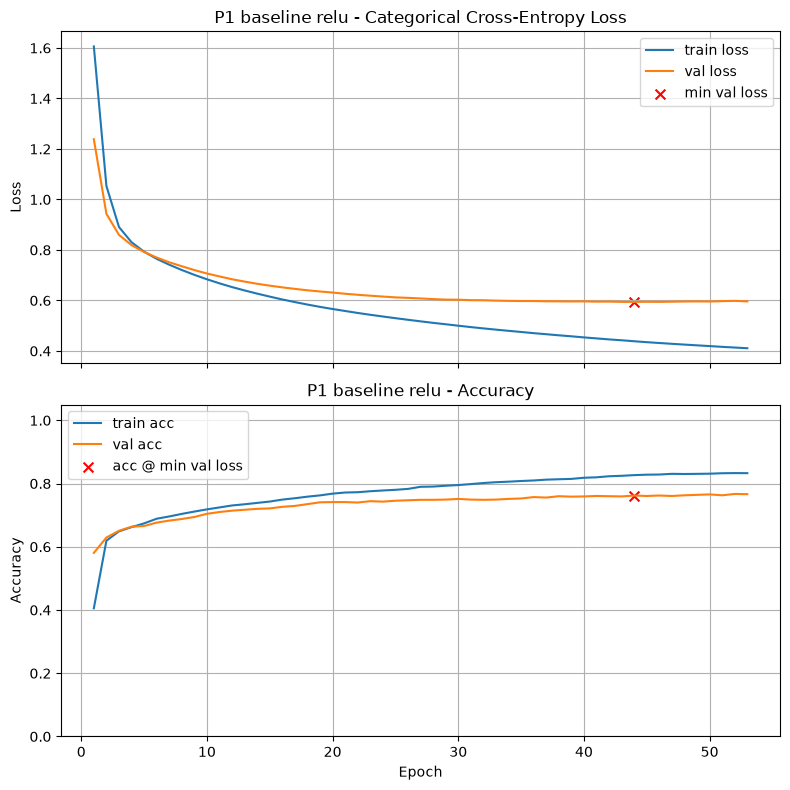

Final Training Loss:            0.4109
Final Training Accuracy:        0.8329
Final Validation Loss:          0.5964
Final Validation Accuracy:      0.7664
Minimum Validation Loss:        0.5943 (Epoch 44)
Validation Accuracy @ Min Loss: 0.7621

Test Loss: 0.6166
Test Accuracy: 0.7436

Validation-Test Gap (accuracy): 0.015714

Execution Time: 00:00:04

P1 baseline sigmoid



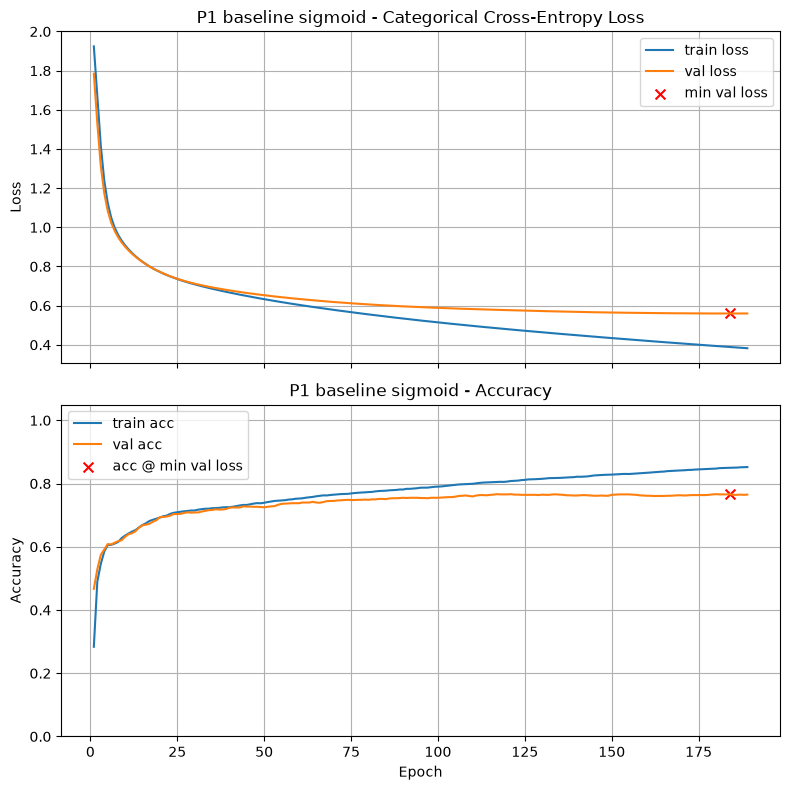

Final Training Loss:            0.3825
Final Training Accuracy:        0.8521
Final Validation Loss:          0.5600
Final Validation Accuracy:      0.7650
Minimum Validation Loss:        0.5599 (Epoch 184)
Validation Accuracy @ Min Loss: 0.7664

Test Loss: 0.5765
Test Accuracy: 0.7693

Validation-Test Gap (accuracy): 0.003571

Execution Time: 00:00:16

P1 baseline tanh



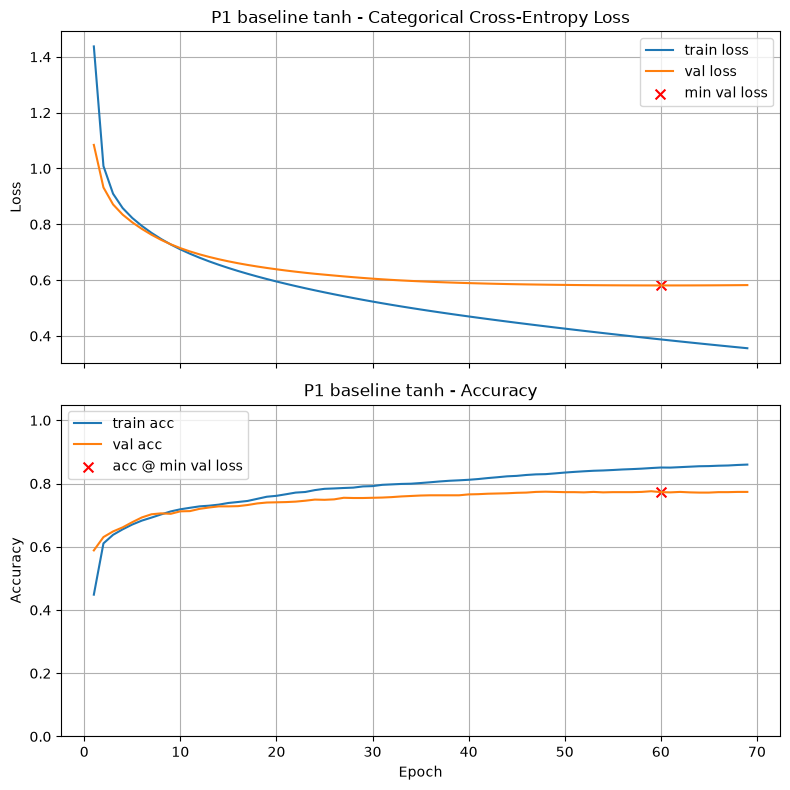

Final Training Loss:            0.3560
Final Training Accuracy:        0.8600
Final Validation Loss:          0.5822
Final Validation Accuracy:      0.7736
Minimum Validation Loss:        0.5810 (Epoch 60)
Validation Accuracy @ Min Loss: 0.7729

Test Loss: 0.6005
Test Accuracy: 0.7543

Validation-Test Gap (accuracy): 0.021429

Execution Time: 00:00:06

  relu     0.7621   (best epoch 44)
  sigmoid  0.7664   (best epoch 184)
  tanh     0.7729   (best epoch 60)

Best activation: tanh


In [10]:
activations = ['relu', 'sigmoid', 'tanh']
p1_results = {}

for act in activations:
    title = f"P1 baseline {act}"
    layer_list = [ (64, act, 0.0, 0.0),
                   (32, act, 0.0, 0.0) ]
    tf.keras.utils.set_random_seed(random_seed)
    model_baseline = build_model(X_train.shape[1], layer_list, n_classes)
    train_and_test(model_baseline, lr_schedule=1e-3, title=title)
    p1_results[act] = results[title]

print()
for act, (acc, ep) in p1_results.items():
    print(f"  {act:<8} {acc:.4f}   (best epoch {ep})")

best_act = max(p1_results, key=lambda a: p1_results[a][0])
print(f"\nBest activation: {best_act}")

### Graded Questions

In [11]:
# Set a1a to the activation function which provided the best validation accuracy at the epoch of minimum validation loss

a1a = 2             # Replace with integer 0 (relu), 1 (sigmoid), or 2 (tanh)

In [12]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a1a = {a1a}') 


a1a = 2


In [13]:
# Set a1b to the validation accuracy found by this best activation function

a1b = 0.7729             # Replace 0.0 with your answer

In [14]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a1b = {a1b:.4f}') 

a1b = 0.7729


### Problem Two: Finding the Right Learning Rate

In this problem, you will continue working with the **baseline model** and determine which learning rate produces the best performance. As before, the model you evaluate should be the one saved by **early stopping** — the epoch where validation loss is minimized.

**Steps to follow:**

* Build and train the **baseline model** using the **activation function identified in Problem One**.

* Train and evaluate this model using each of the following learning rates:

  ```
      [1e-3, 5e-4, 1e-4, 5e-5, 1e-5]
  ```

* Identify which learning rate produces the **best validation accuracy** at the epoch of **minimum validation loss**, within a maximum of **500 epochs**.

* Answer the graded questions.


**Note: Smaller learning rates will generally take more epochs to reach the optimal point, so some of these will not engage early stopping, but run the full 500 epochs.**



P2 lr=0.001



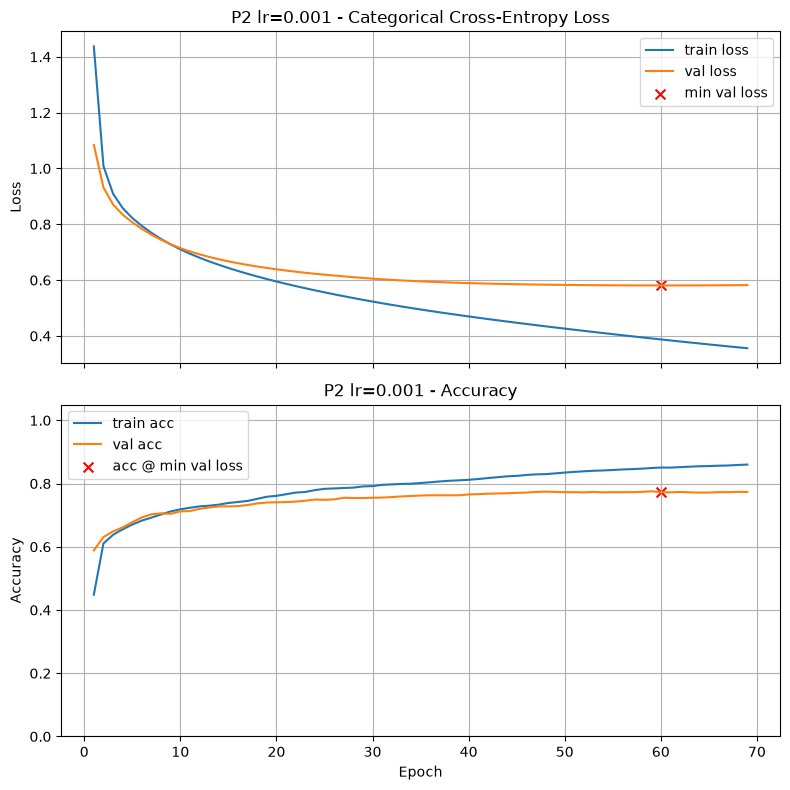

Final Training Loss:            0.3560
Final Training Accuracy:        0.8600
Final Validation Loss:          0.5822
Final Validation Accuracy:      0.7736
Minimum Validation Loss:        0.5810 (Epoch 60)
Validation Accuracy @ Min Loss: 0.7729

Test Loss: 0.6005
Test Accuracy: 0.7543

Validation-Test Gap (accuracy): 0.021429

Execution Time: 00:00:06

P2 lr=0.0005



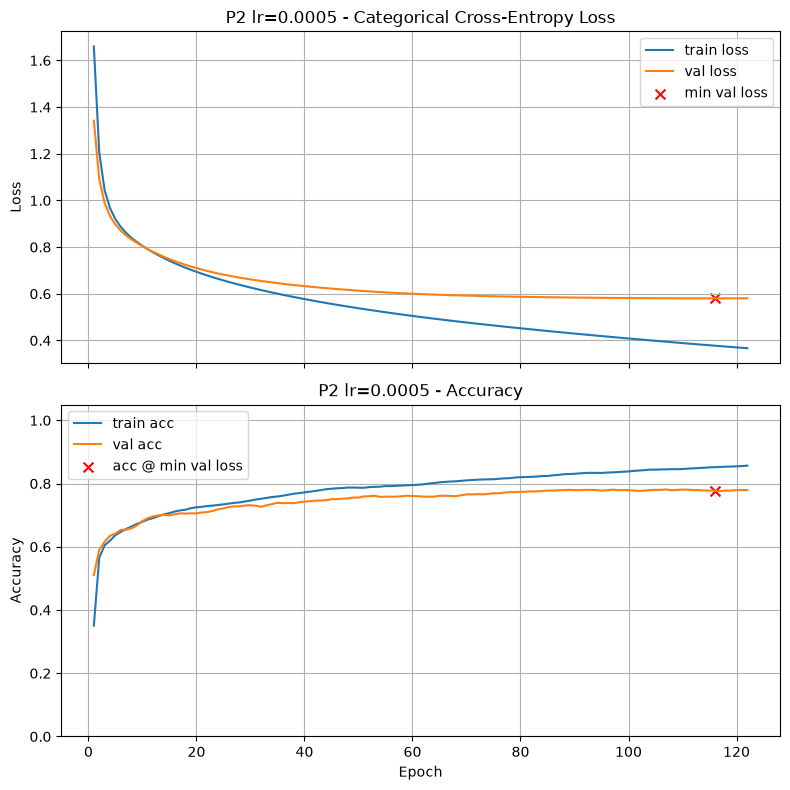

Final Training Loss:            0.3667
Final Training Accuracy:        0.8567
Final Validation Loss:          0.5806
Final Validation Accuracy:      0.7793
Minimum Validation Loss:        0.5804 (Epoch 116)
Validation Accuracy @ Min Loss: 0.7771

Test Loss: 0.5977
Test Accuracy: 0.7500

Validation-Test Gap (accuracy): 0.029286

Execution Time: 00:00:10

P2 lr=0.0001



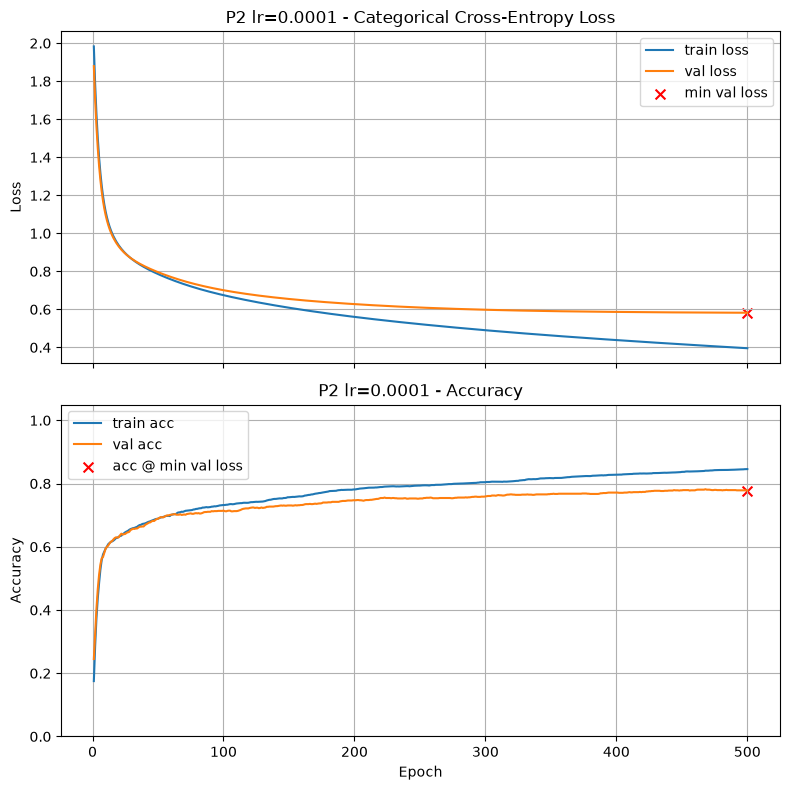

Final Training Loss:            0.3957
Final Training Accuracy:        0.8457
Final Validation Loss:          0.5824
Final Validation Accuracy:      0.7779
Minimum Validation Loss:        0.5824 (Epoch 500)
Validation Accuracy @ Min Loss: 0.7779

Test Loss: 0.5950
Test Accuracy: 0.7493

Validation-Test Gap (accuracy): 0.029286

Execution Time: 00:00:42

P2 lr=5e-05



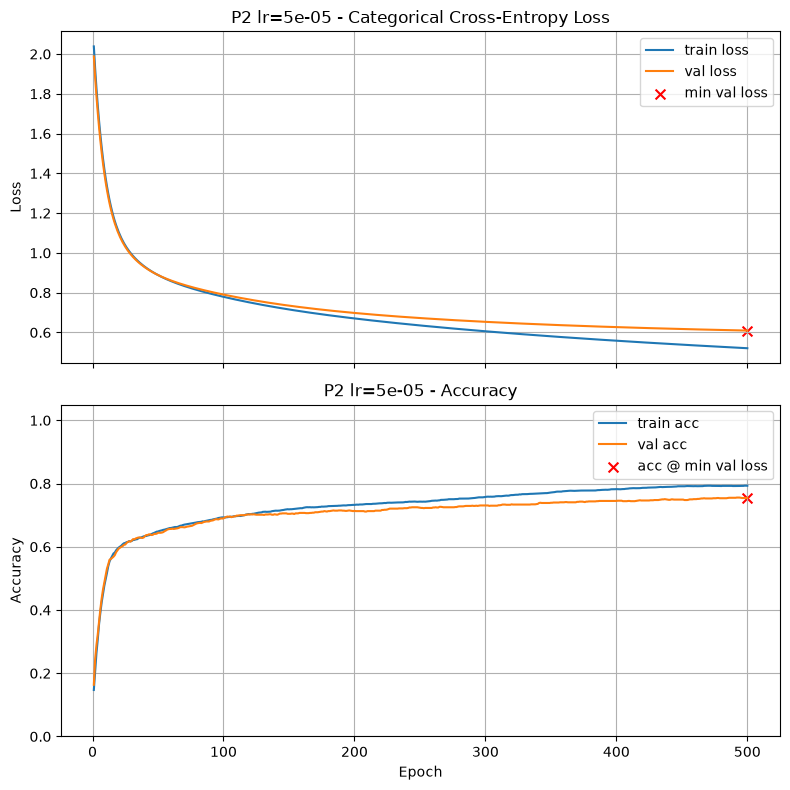

Final Training Loss:            0.5208
Final Training Accuracy:        0.7931
Final Validation Loss:          0.6095
Final Validation Accuracy:      0.7543
Minimum Validation Loss:        0.6095 (Epoch 500)
Validation Accuracy @ Min Loss: 0.7543

Test Loss: 0.6204
Test Accuracy: 0.7364

Validation-Test Gap (accuracy): 0.017857

Execution Time: 00:00:41

P2 lr=1e-05



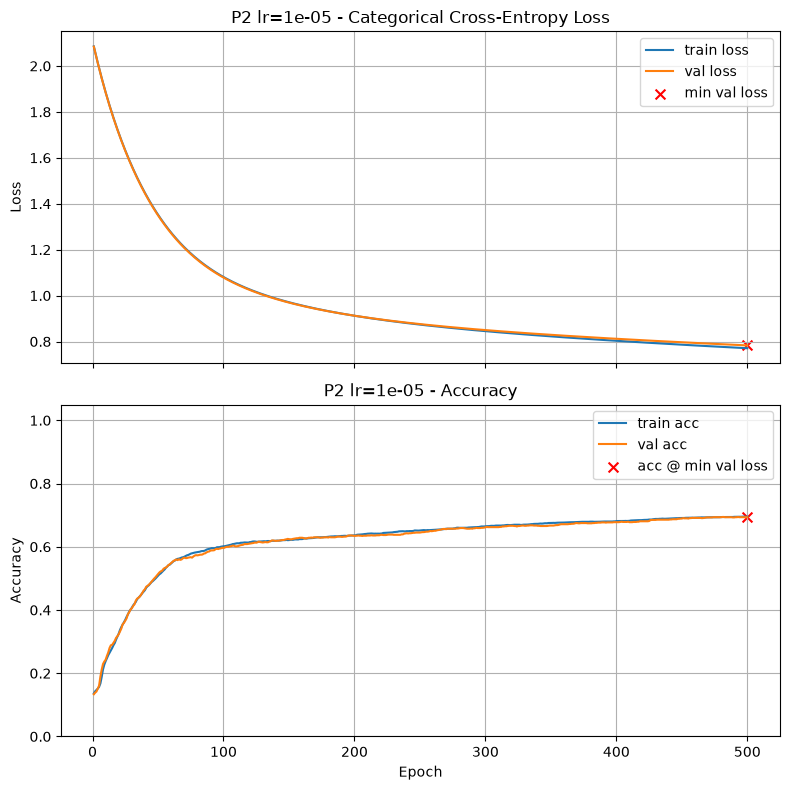

Final Training Loss:            0.7707
Final Training Accuracy:        0.6950
Final Validation Loss:          0.7830
Final Validation Accuracy:      0.6936
Minimum Validation Loss:        0.7830 (Epoch 500)
Validation Accuracy @ Min Loss: 0.6936

Test Loss: 0.7964
Test Accuracy: 0.6964

Validation-Test Gap (accuracy): 0.002857

Execution Time: 00:00:41

  lr=0.001    0.7729   (best epoch 60)
  lr=0.0005   0.7771   (best epoch 116)
  lr=0.0001   0.7779   (best epoch 500)
  lr=5e-05    0.7543   (best epoch 500)
  lr=1e-05    0.6936   (best epoch 500)

Best learning rate: 0.0001


In [15]:
learning_rates = [1e-3, 5e-4, 1e-4, 5e-5, 1e-5]
p2_results = {}

for lr in learning_rates:
    layer_list = [ (64, best_act, 0.0, 0.0),
                   (32, best_act, 0.0, 0.0) ]
    p2_results[lr] = run_experiment(layer_list, lr=lr, epochs=500, title=f"P2 lr={lr}")

print()
for lr, (acc, ep) in p2_results.items():
    print(f"  lr={lr:<8} {acc:.4f}   (best epoch {ep})")

best_lr = max(p2_results, key=lambda k: p2_results[k][0])
print(f"\nBest learning rate: {best_lr}")

#### Graded Questions

In [16]:
# Set a2a to the learning rate which provided the best validation accuracy at the epoch of minimum validation loss

a2a = 1e-4           # Replace 0.0 with your answer

In [17]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a2a = {a2a:.6f}') 

a2a = 0.000100


In [18]:
# Set a2b to the validation accuracy found by this best learning rate

a2b = 0.7779             # Replace 0.0 with your answer

In [19]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a2b = {a2b:.4f}') 

a2b = 0.7779


### Problem Three: Dropout

In this problem, you will explore how **dropout** can help prevent overfitting in neural networks. There are no absolute rules, but some useful heuristics are:

* Dropout typically works best in **later dense layers** (e.g., the second hidden layer of width 32) in the range **0.3–0.5**.
* If applied to **earlier layers** (e.g., the first hidden layer), dropout should be smaller, typically **0.0–0.2** (where 0.0 means no dropout).

**Steps to follow:**

* Build and train the **baseline model** using the **activation function from Problem One** and the **learning rate from Problem Two**.
* Investigate dropout in the ranges suggested, using increments of **0.1**.
* Identify which dropout configuration produces the **best validation accuracy** at the epoch of **minimum validation loss**.
* Answer the graded questions.



P3 dropout=(0.0,0.3)



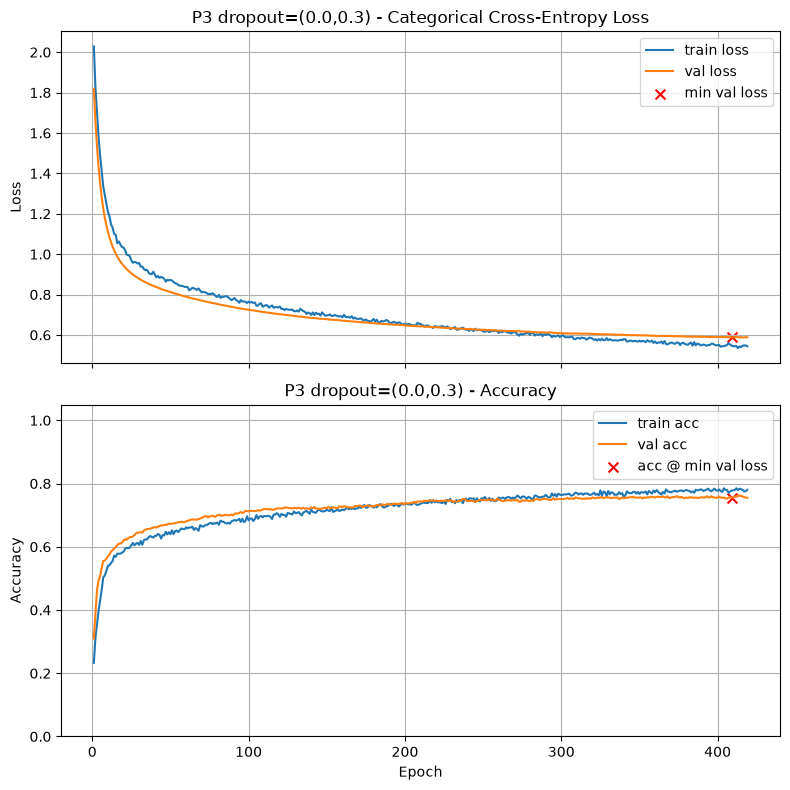

Final Training Loss:            0.5437
Final Training Accuracy:        0.7800
Final Validation Loss:          0.5881
Final Validation Accuracy:      0.7550
Minimum Validation Loss:        0.5878 (Epoch 409)
Validation Accuracy @ Min Loss: 0.7557

Test Loss: 0.6016
Test Accuracy: 0.7500

Validation-Test Gap (accuracy): 0.005714

Execution Time: 00:00:36

P3 dropout=(0.0,0.4)



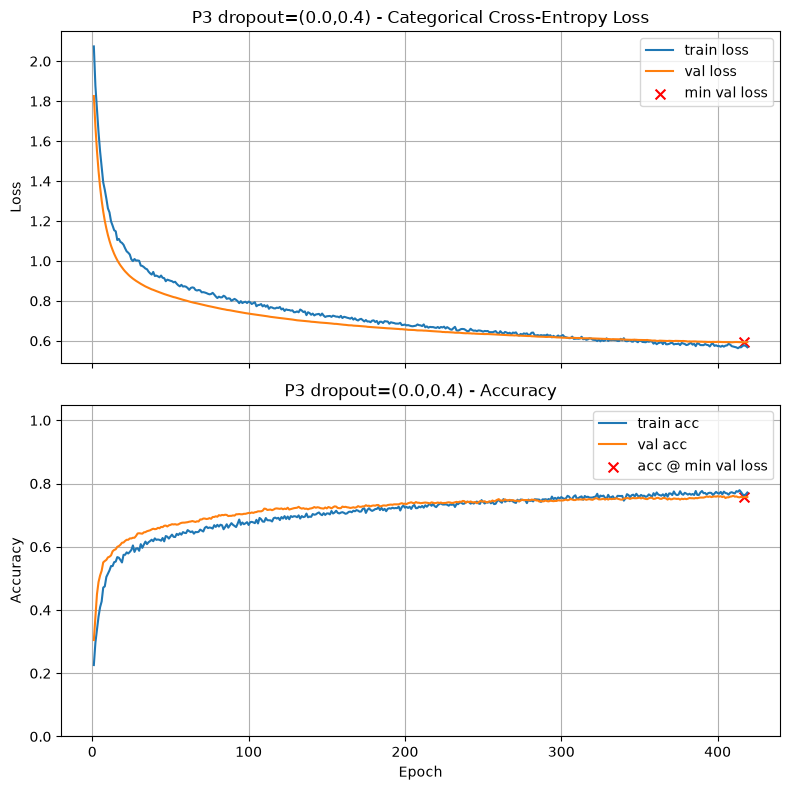

Final Training Loss:            0.5677
Final Training Accuracy:        0.7717
Final Validation Loss:          0.5934
Final Validation Accuracy:      0.7571
Minimum Validation Loss:        0.5925 (Epoch 417)
Validation Accuracy @ Min Loss: 0.7571

Test Loss: 0.6106
Test Accuracy: 0.7414

Validation-Test Gap (accuracy): 0.017857

Execution Time: 00:00:35

P3 dropout=(0.0,0.5)



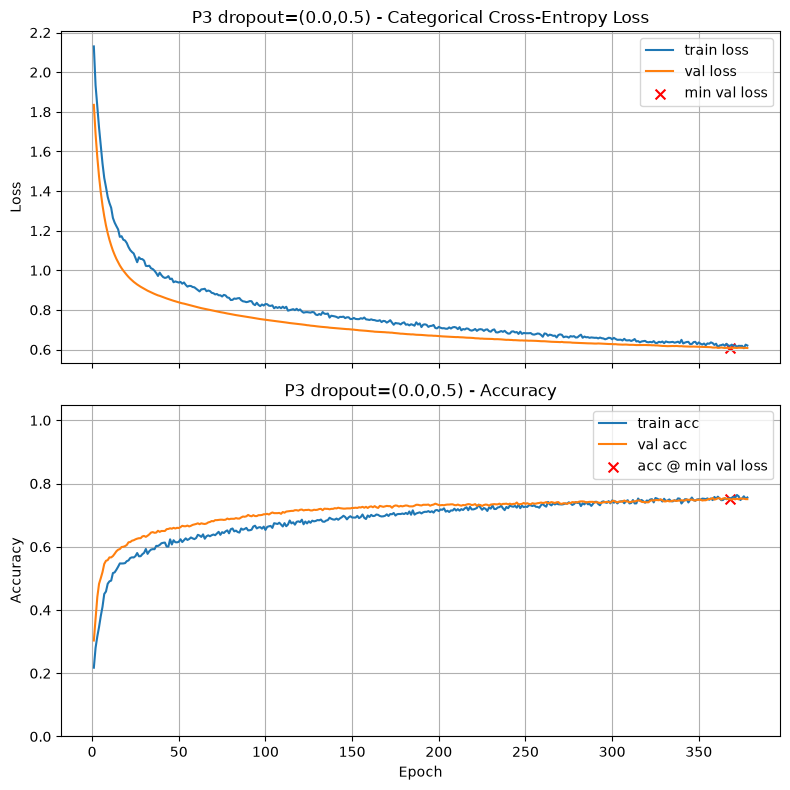

Final Training Loss:            0.6204
Final Training Accuracy:        0.7560
Final Validation Loss:          0.6078
Final Validation Accuracy:      0.7507
Minimum Validation Loss:        0.6076 (Epoch 368)
Validation Accuracy @ Min Loss: 0.7507

Test Loss: 0.6308
Test Accuracy: 0.7343

Validation-Test Gap (accuracy): 0.016429

Execution Time: 00:00:32

P3 dropout=(0.1,0.3)



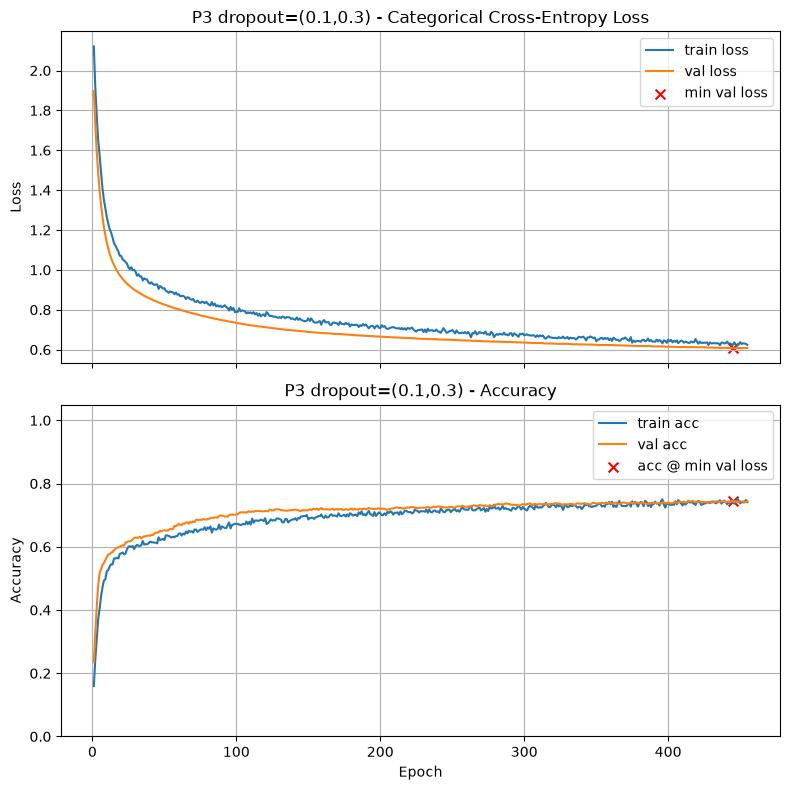

Final Training Loss:            0.6243
Final Training Accuracy:        0.7414
Final Validation Loss:          0.6076
Final Validation Accuracy:      0.7436
Minimum Validation Loss:        0.6071 (Epoch 445)
Validation Accuracy @ Min Loss: 0.7457

Test Loss: 0.6252
Test Accuracy: 0.7471

Validation-Test Gap (accuracy): 0.001429

Execution Time: 00:00:39

P3 dropout=(0.1,0.4)



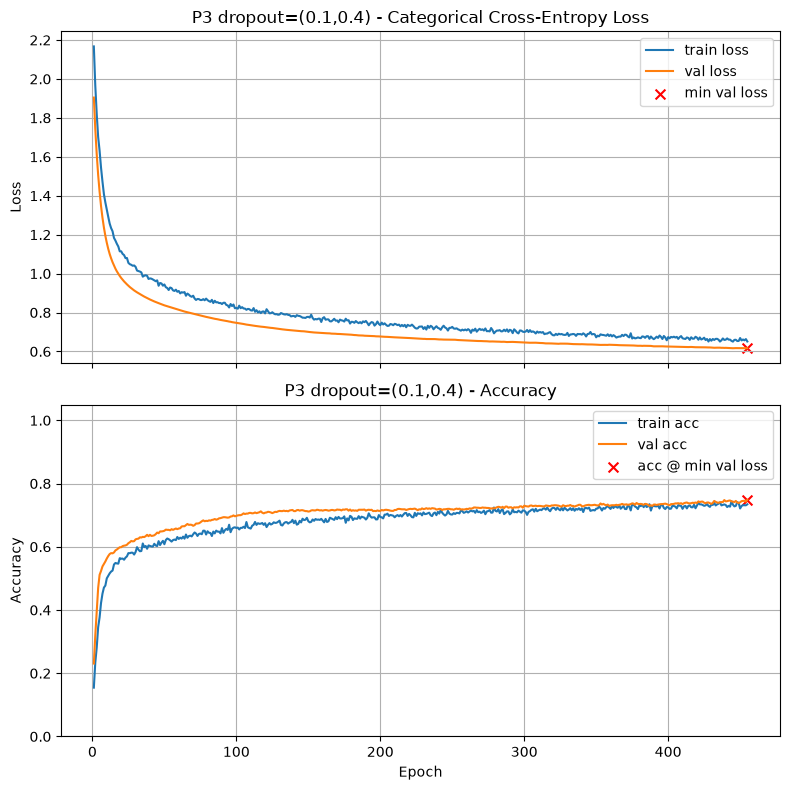

Final Training Loss:            0.6513
Final Training Accuracy:        0.7343
Final Validation Loss:          0.6166
Final Validation Accuracy:      0.7486
Minimum Validation Loss:        0.6166 (Epoch 455)
Validation Accuracy @ Min Loss: 0.7486

Test Loss: 0.6386
Test Accuracy: 0.7436

Validation-Test Gap (accuracy): 0.000714

Execution Time: 00:00:39

P3 dropout=(0.1,0.5)



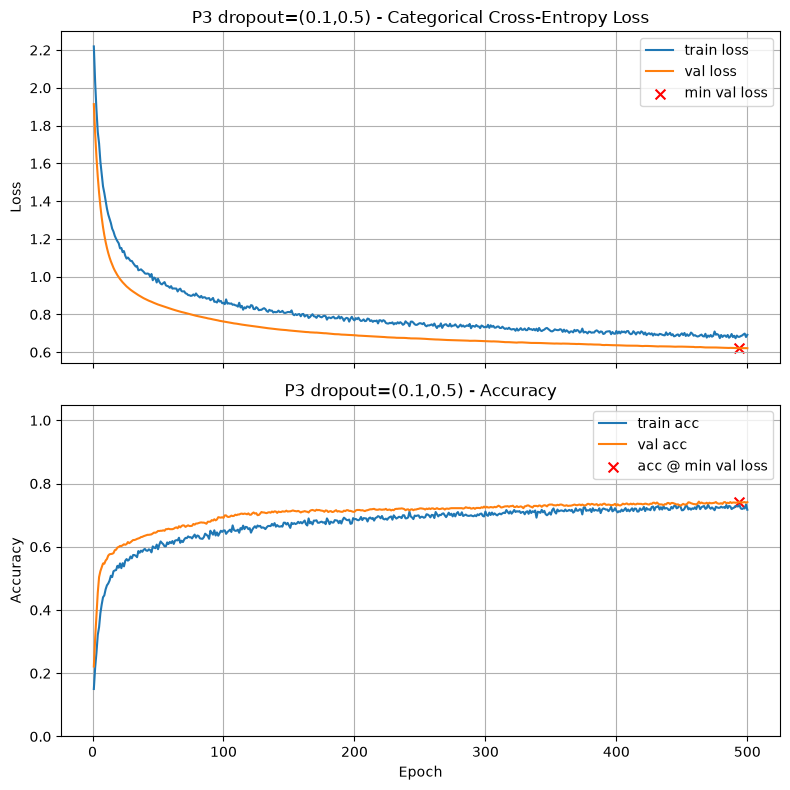

Final Training Loss:            0.6921
Final Training Accuracy:        0.7171
Final Validation Loss:          0.6214
Final Validation Accuracy:      0.7414
Minimum Validation Loss:        0.6211 (Epoch 494)
Validation Accuracy @ Min Loss: 0.7421

Test Loss: 0.6469
Test Accuracy: 0.7357

Validation-Test Gap (accuracy): 0.006429

Execution Time: 00:00:43

P3 dropout=(0.2,0.3)



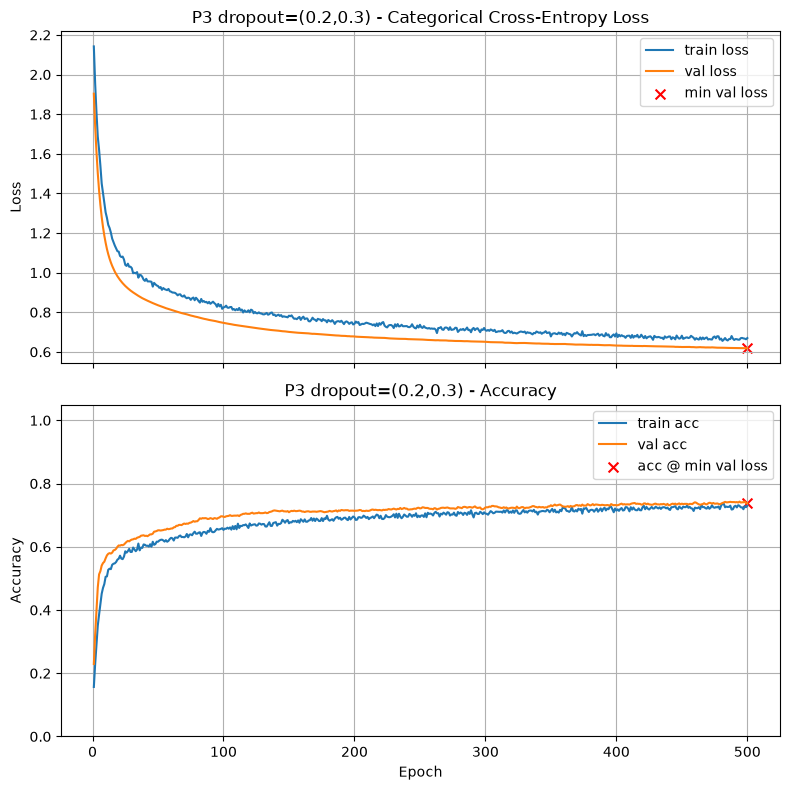

Final Training Loss:            0.6697
Final Training Accuracy:        0.7298
Final Validation Loss:          0.6184
Final Validation Accuracy:      0.7379
Minimum Validation Loss:        0.6184 (Epoch 500)
Validation Accuracy @ Min Loss: 0.7379

Test Loss: 0.6436
Test Accuracy: 0.7350

Validation-Test Gap (accuracy): 0.002857

Execution Time: 00:00:44

P3 dropout=(0.2,0.4)



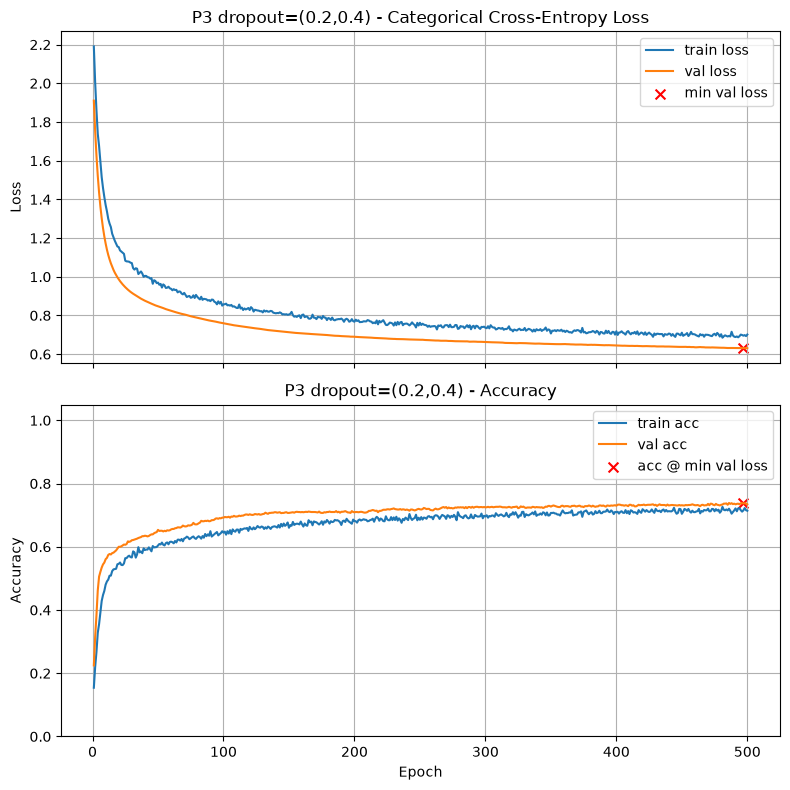

Final Training Loss:            0.7012
Final Training Accuracy:        0.7140
Final Validation Loss:          0.6308
Final Validation Accuracy:      0.7343
Minimum Validation Loss:        0.6306 (Epoch 497)
Validation Accuracy @ Min Loss: 0.7371

Test Loss: 0.6588
Test Accuracy: 0.7336

Validation-Test Gap (accuracy): 0.003571

Execution Time: 00:00:44

P3 dropout=(0.2,0.5)



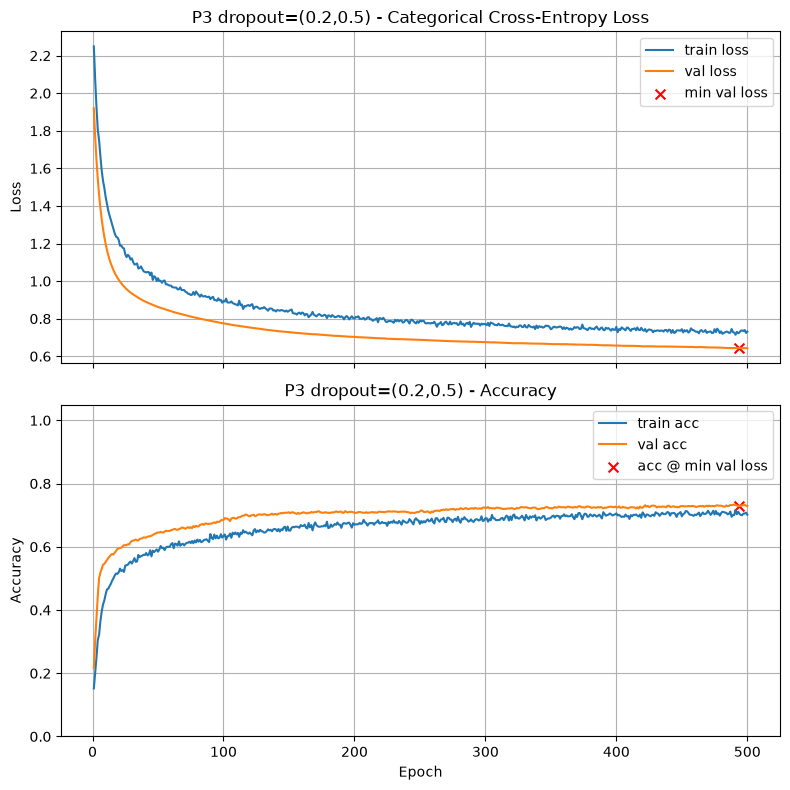

Final Training Loss:            0.7316
Final Training Accuracy:        0.7014
Final Validation Loss:          0.6433
Final Validation Accuracy:      0.7293
Minimum Validation Loss:        0.6428 (Epoch 494)
Validation Accuracy @ Min Loss: 0.7286

Test Loss: 0.6722
Test Accuracy: 0.7271

Validation-Test Gap (accuracy): 0.001429

Execution Time: 00:00:44

  dropout=(0.0,0.3)  0.7557   (best epoch 409)
  dropout=(0.0,0.4)  0.7571   (best epoch 417)
  dropout=(0.0,0.5)  0.7507   (best epoch 368)
  dropout=(0.1,0.3)  0.7457   (best epoch 445)
  dropout=(0.1,0.4)  0.7486   (best epoch 455)
  dropout=(0.1,0.5)  0.7421   (best epoch 494)
  dropout=(0.2,0.3)  0.7379   (best epoch 500)
  dropout=(0.2,0.4)  0.7371   (best epoch 497)
  dropout=(0.2,0.5)  0.7286   (best epoch 494)

Best dropout (64, 32): (0.0, 0.4)


In [20]:
p3_results = {}

for d64 in [0.0, 0.1, 0.2]:
    for d32 in [0.3, 0.4, 0.5]:
        layer_list = [ (64, best_act, 0.0, d64),
                       (32, best_act, 0.0, d32) ]
        p3_results[(d64, d32)] = run_experiment(layer_list, lr=best_lr, title=f"P3 dropout=({d64},{d32})")

print()
for (d64, d32), (acc, ep) in p3_results.items():
    print(f"  dropout=({d64},{d32})  {acc:.4f}   (best epoch {ep})")

best_dropout = max(p3_results, key=lambda k: p3_results[k][0])
print(f"\nBest dropout (64, 32): {best_dropout}")

In [21]:
# Set a3a to the pair (dropout_rate_64,dropout_rate_32) of dropout rates for the two hidden layers which provided the best 
# validation accuracy at the epoch of minimum validation loss

a3a = (0.0,0.4)             # Replace (0.0,0.0) with your answer

In [22]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a3a = {a3a}') 

a3a = (0.0, 0.4)


In [23]:
# Set a3b to the validation accuracy found by this best pair of dropout rates

a3b = 0.7571             # Replace 0.0 with your answer

In [24]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a3b = {a3b:.4f}') 

a3b = 0.7571


### Problem Four: L2 Regularization

In this problem, you will explore how **L2 regularization** (also called *weight decay*) can help prevent overfitting in neural networks. There are no absolute rules, but some useful heuristics are:

* Start simply by using the **same λ in both hidden layers**, with values:

  ```
      1e-4, 1e-3, 1e-2
  ```

* If validation results suggest underfitting in the first layer or persistent overfitting in the later one, then try adjusting per layer, for example:

  * First hidden layer: λ = 1e-4
  * Second hidden layer: λ = 1e-3

**Steps to follow:**

* Build and train the **baseline model** using the **activation function from Problem One** and the **learning rate from Problem Two**, but **without dropout**.
* Investigate at least the four cases suggested (three with the same λ and one with different λ values). You may also consider additional combinations.
* Identify which configuration produces the **best validation accuracy** at the epoch of **minimum validation loss**.
* Answer the graded questions.



P4 L2=(0.0001,0.0001)



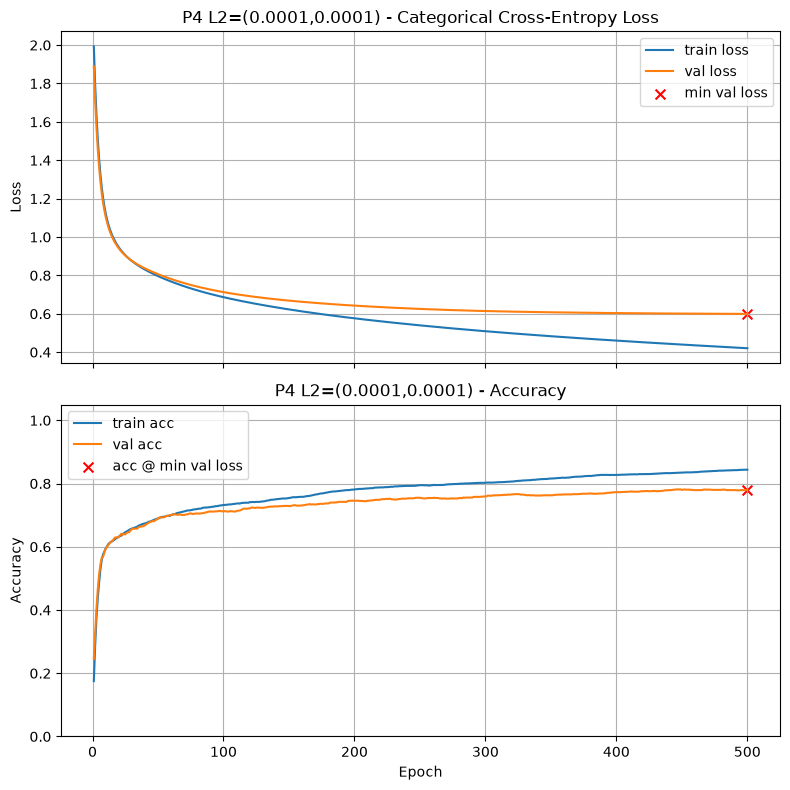

Final Training Loss:            0.4205
Final Training Accuracy:        0.8438
Final Validation Loss:          0.5994
Final Validation Accuracy:      0.7793
Minimum Validation Loss:        0.5994 (Epoch 500)
Validation Accuracy @ Min Loss: 0.7793

Test Loss: 0.6121
Test Accuracy: 0.7500

Validation-Test Gap (accuracy): 0.029286

Execution Time: 00:00:42

P4 L2=(0.001,0.001)



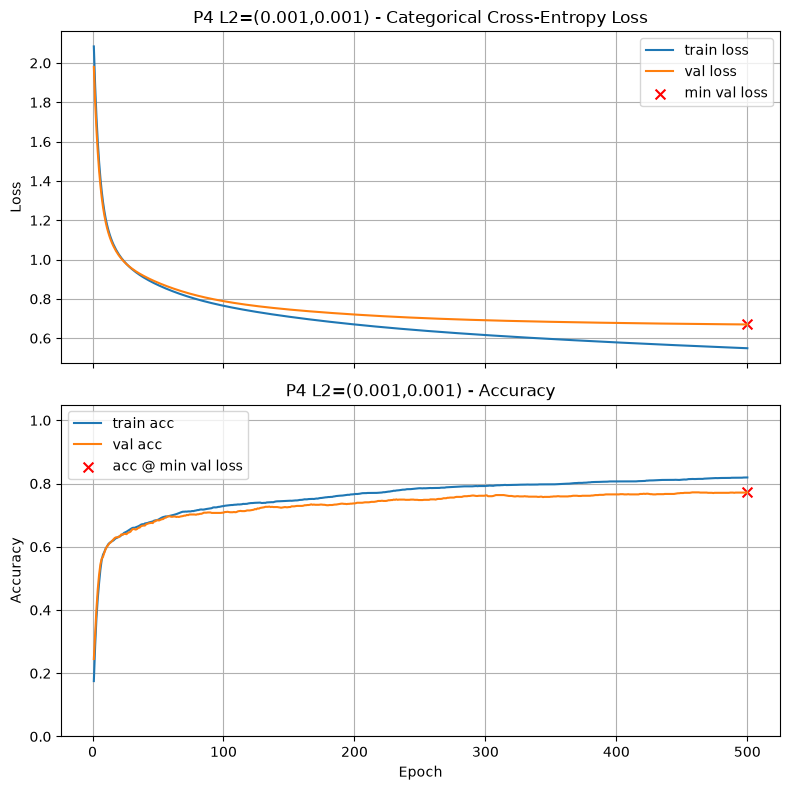

Final Training Loss:            0.5491
Final Training Accuracy:        0.8193
Final Validation Loss:          0.6700
Final Validation Accuracy:      0.7721
Minimum Validation Loss:        0.6700 (Epoch 500)
Validation Accuracy @ Min Loss: 0.7721

Test Loss: 0.6851
Test Accuracy: 0.7421

Validation-Test Gap (accuracy): 0.030000

Execution Time: 00:00:42

P4 L2=(0.01,0.01)



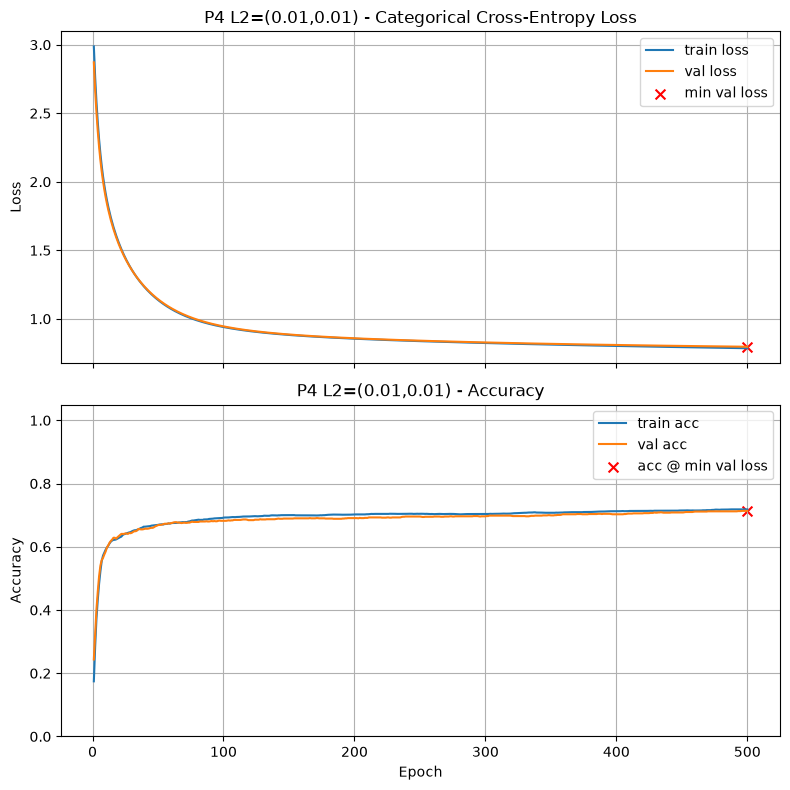

Final Training Loss:            0.7854
Final Training Accuracy:        0.7183
Final Validation Loss:          0.7961
Final Validation Accuracy:      0.7136
Minimum Validation Loss:        0.7961 (Epoch 500)
Validation Accuracy @ Min Loss: 0.7136

Test Loss: 0.8149
Test Accuracy: 0.7107

Validation-Test Gap (accuracy): 0.002857

Execution Time: 00:00:42

P4 L2=(0.0001,0.001)



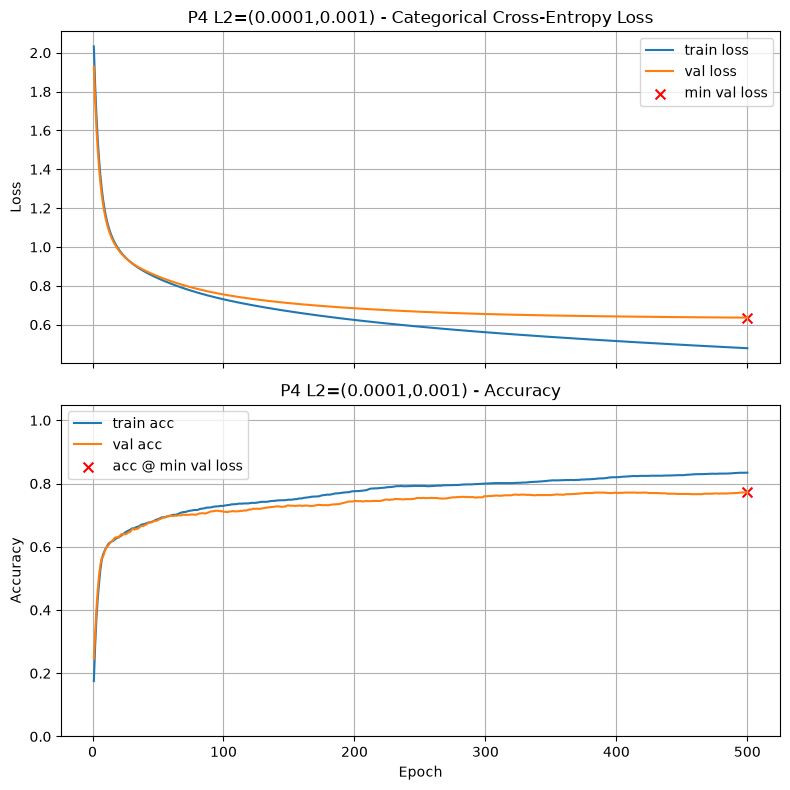

Final Training Loss:            0.4786
Final Training Accuracy:        0.8345
Final Validation Loss:          0.6362
Final Validation Accuracy:      0.7721
Minimum Validation Loss:        0.6362 (Epoch 500)
Validation Accuracy @ Min Loss: 0.7721

Test Loss: 0.6474
Test Accuracy: 0.7436

Validation-Test Gap (accuracy): 0.028571

Execution Time: 00:00:42

P4 L2=(0.001,0.0001)



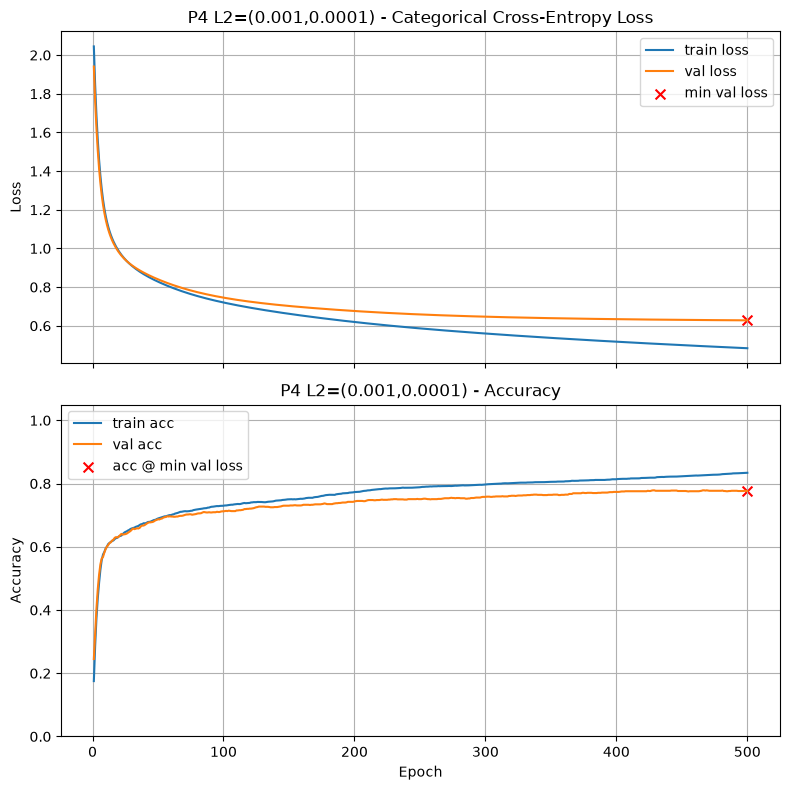

Final Training Loss:            0.4838
Final Training Accuracy:        0.8340
Final Validation Loss:          0.6281
Final Validation Accuracy:      0.7764
Minimum Validation Loss:        0.6281 (Epoch 500)
Validation Accuracy @ Min Loss: 0.7764

Test Loss: 0.6417
Test Accuracy: 0.7450

Validation-Test Gap (accuracy): 0.032143

Execution Time: 00:00:42

P4 L2=(0.001,0.01)



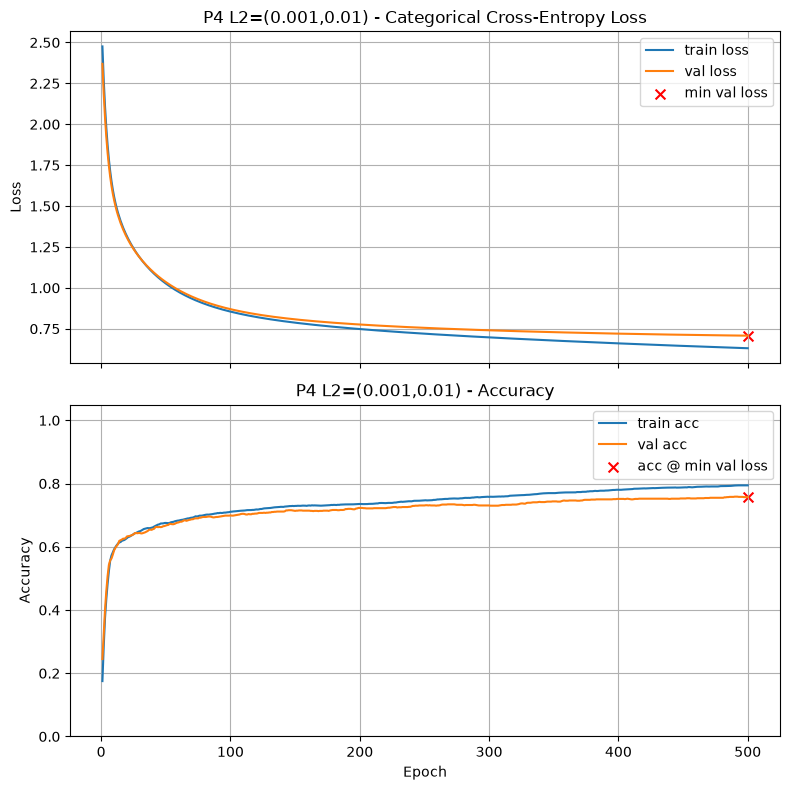

Final Training Loss:            0.6310
Final Training Accuracy:        0.7943
Final Validation Loss:          0.7078
Final Validation Accuracy:      0.7571
Minimum Validation Loss:        0.7078 (Epoch 500)
Validation Accuracy @ Min Loss: 0.7571

Test Loss: 0.7203
Test Accuracy: 0.7471

Validation-Test Gap (accuracy): 0.010000

Execution Time: 00:00:42

  L2=(0.0001,0.0001)  0.7793   (best epoch 500)
  L2=(0.001,0.001)  0.7721   (best epoch 500)
  L2=(0.01,0.01)  0.7136   (best epoch 500)
  L2=(0.0001,0.001)  0.7721   (best epoch 500)
  L2=(0.001,0.0001)  0.7764   (best epoch 500)
  L2=(0.001,0.01)  0.7571   (best epoch 500)

Best L2 (64, 32): (0.0001, 0.0001)


In [25]:
l2_pairs = [(1e-4, 1e-4), (1e-3, 1e-3), (1e-2, 1e-2), (1e-4, 1e-3), (1e-3, 1e-4), (1e-3, 1e-2)]
p4_results = {}

for (l64, l32) in l2_pairs:
    layer_list = [ (64, best_act, l64, 0.0),
                   (32, best_act, l32, 0.0) ]
    p4_results[(l64, l32)] = run_experiment(layer_list, lr=best_lr, title=f"P4 L2=({l64},{l32})")

print()
for (l64, l32), (acc, ep) in p4_results.items():
    print(f"  L2=({l64},{l32})  {acc:.4f}   (best epoch {ep})")

best_l2 = max(p4_results, key=lambda k: p4_results[k][0])
print(f"\nBest L2 (64, 32): {best_l2}")

In [26]:
# Set a4a to the pair (L2_lambda_64,L2_lambda_32) of the L2 lambdas for the two hidden layers which provided the best 
# validation accuracy at the epoch of minimum validation loss

a4a = (1e-4,1e-4)             # Replace (0.0,0.0) with your answer

In [27]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a4a = {a4a}') 

a4a = (0.0001, 0.0001)


In [28]:
# Set a4b to the validation accuracy found by this best pair of lambdas

a4b = 0.7793             # Replace 0.0 with your answer

In [29]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a4b = {a4b:.4f}') 

a4b = 0.7793


### Problem Five: Combining Dropout with L2 Regularization

In this problem, you will explore how **dropout** and **L2 regularization** can work together to prevent overfitting. These two methods complement each other, but must be balanced carefully. A useful rule of thumb is:

* If dropout is **high**, use a **smaller λ**.
* If dropout is **low**, you can afford a **larger λ**.

**Steps to follow:**

* Build and train the **baseline model** using the **activation function from Problem One** and the **learning rate from Problem Two**.
* Investigate combinations of dropout and L2:

  * First, use the **dropout rate you identified in Problem Three** as a baseline.
  * Then, add L2 to both hidden layers with values:

    ```
        1e-4, 1e-3, 1e-2
    ```

    while keeping dropout fixed.
  * Finally, try **reducing dropout slightly** when L2 is added to see if performance improves.
  * [Optional] You may wish to investigate other combinations not covered here; for example, promising but not optimal choices of dropout rates may provide overall better performance when combines with L2 Regulari 
* Identify which combination produces the **best validation accuracy** at the epoch of **minimum validation loss**.
* Answer the graded questions.




P5 dropout=(0.0,0.4) L2=0.0001



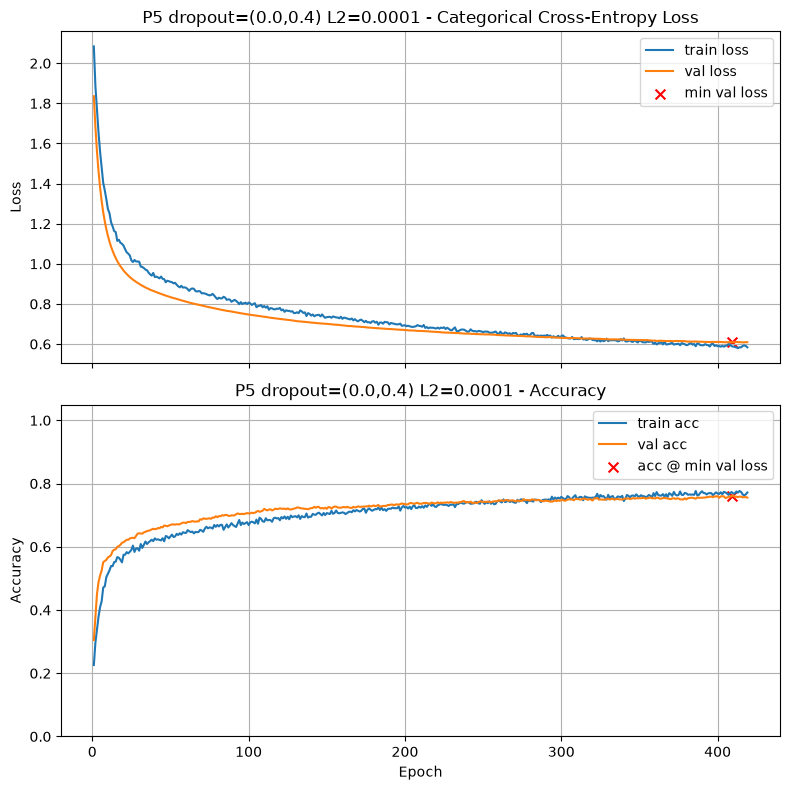

Final Training Loss:            0.5839
Final Training Accuracy:        0.7717
Final Validation Loss:          0.6093
Final Validation Accuracy:      0.7557
Minimum Validation Loss:        0.6083 (Epoch 409)
Validation Accuracy @ Min Loss: 0.7600

Test Loss: 0.6270
Test Accuracy: 0.7393

Validation-Test Gap (accuracy): 0.020714

Execution Time: 00:00:37

P5 dropout=(0.0,0.4) L2=0.001



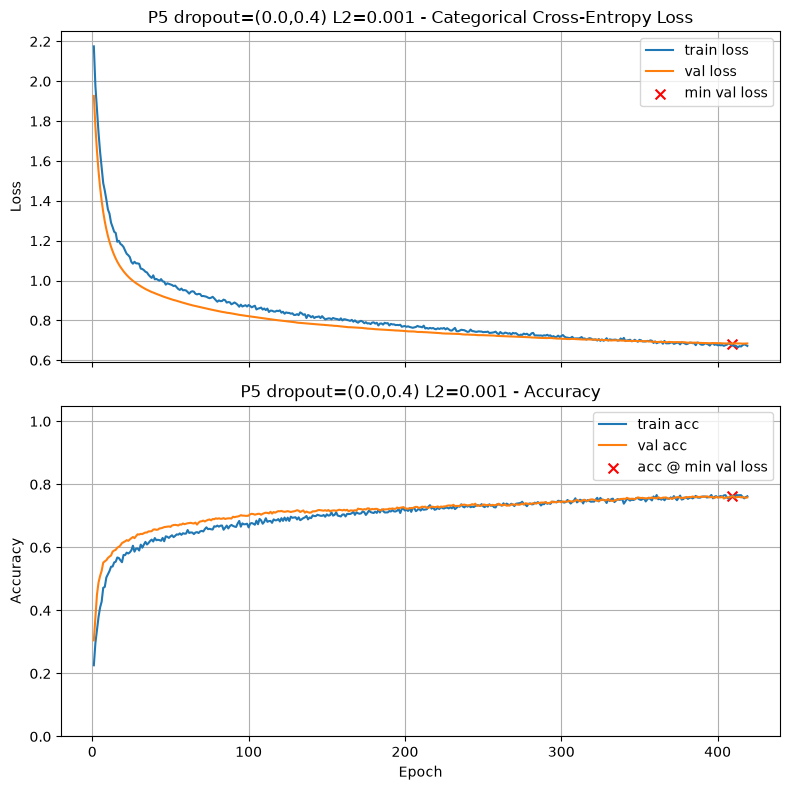

Final Training Loss:            0.6720
Final Training Accuracy:        0.7621
Final Validation Loss:          0.6843
Final Validation Accuracy:      0.7586
Minimum Validation Loss:        0.6829 (Epoch 409)
Validation Accuracy @ Min Loss: 0.7614

Test Loss: 0.7025
Test Accuracy: 0.7350

Validation-Test Gap (accuracy): 0.026429

Execution Time: 00:00:36

P5 dropout=(0.0,0.4) L2=0.01



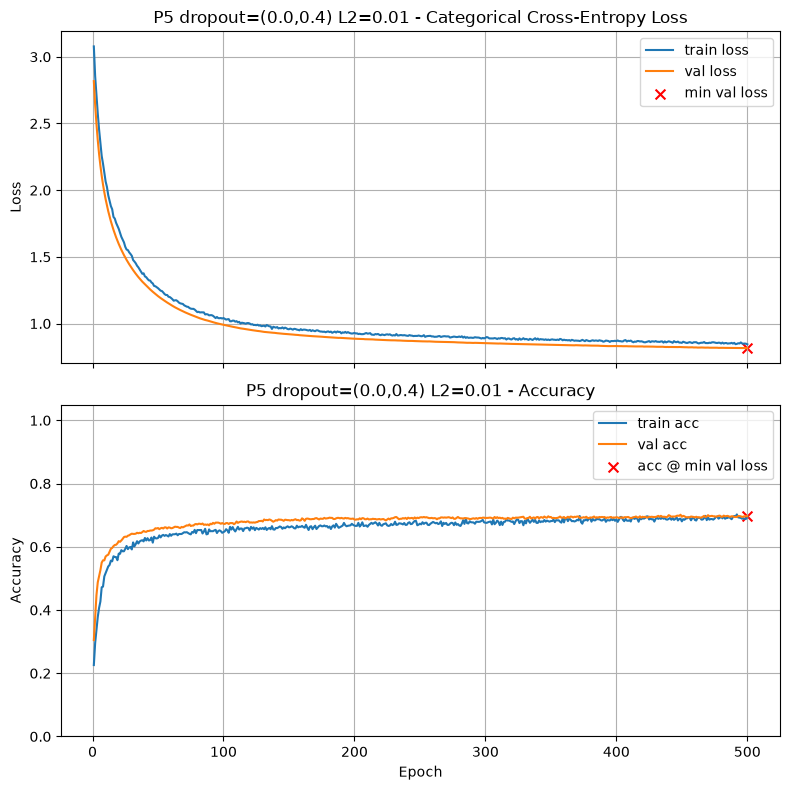

Final Training Loss:            0.8442
Final Training Accuracy:        0.6931
Final Validation Loss:          0.8150
Final Validation Accuracy:      0.6964
Minimum Validation Loss:        0.8150 (Epoch 500)
Validation Accuracy @ Min Loss: 0.6964

Test Loss: 0.8358
Test Accuracy: 0.6929

Validation-Test Gap (accuracy): 0.003571

Execution Time: 00:00:43

P5 dropout=(0.0,0.3) L2=0.0001



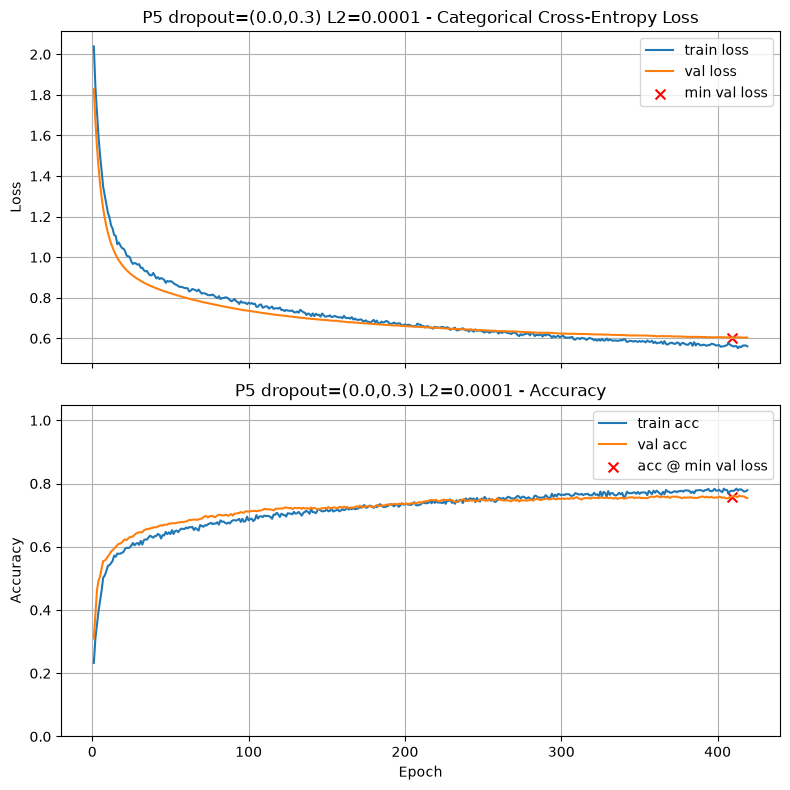

Final Training Loss:            0.5611
Final Training Accuracy:        0.7788
Final Validation Loss:          0.6040
Final Validation Accuracy:      0.7543
Minimum Validation Loss:        0.6034 (Epoch 409)
Validation Accuracy @ Min Loss: 0.7586

Test Loss: 0.6180
Test Accuracy: 0.7493

Validation-Test Gap (accuracy): 0.009286

Execution Time: 00:00:36

P5 dropout=(0.0,0.3) L2=0.001



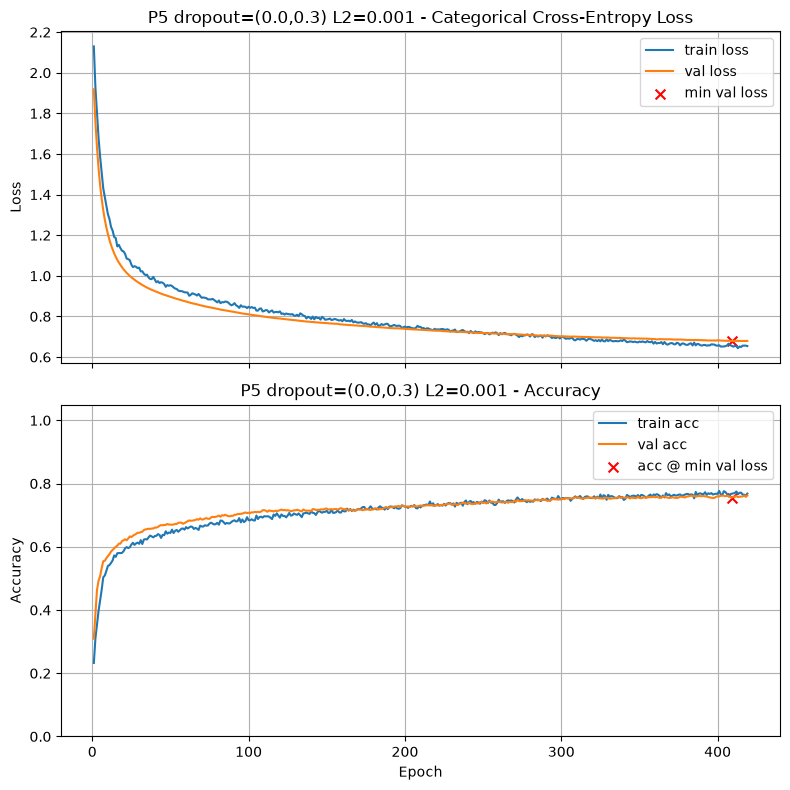

Final Training Loss:            0.6542
Final Training Accuracy:        0.7683
Final Validation Loss:          0.6794
Final Validation Accuracy:      0.7621
Minimum Validation Loss:        0.6787 (Epoch 409)
Validation Accuracy @ Min Loss: 0.7557

Test Loss: 0.6971
Test Accuracy: 0.7407

Validation-Test Gap (accuracy): 0.015000

Execution Time: 00:00:36

P5 dropout=(0.0,0.3) L2=0.01



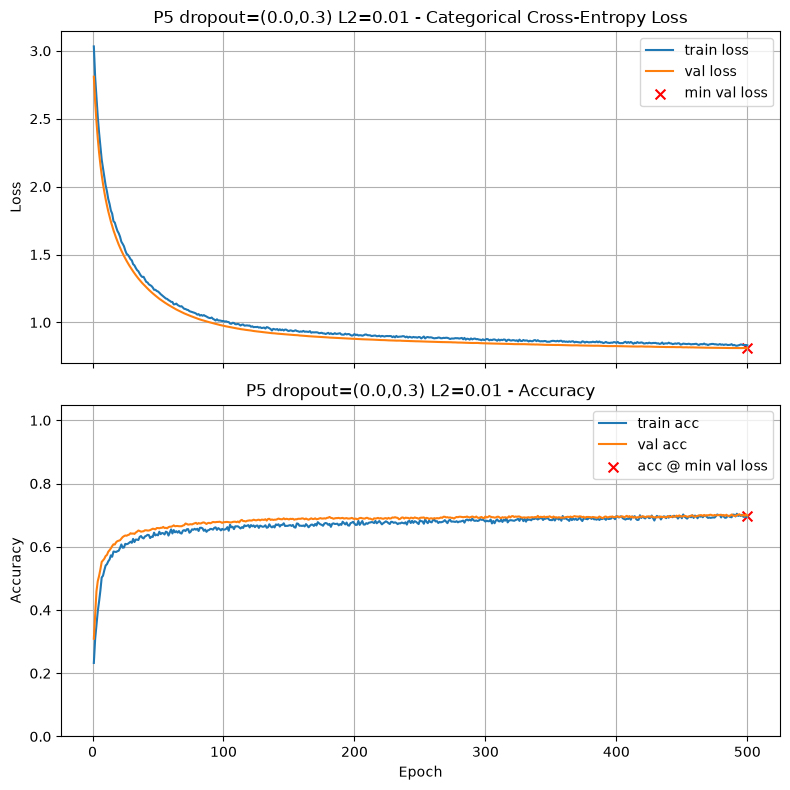

Final Training Loss:            0.8313
Final Training Accuracy:        0.6957
Final Validation Loss:          0.8098
Final Validation Accuracy:      0.6986
Minimum Validation Loss:        0.8098 (Epoch 500)
Validation Accuracy @ Min Loss: 0.6986

Test Loss: 0.8291
Test Accuracy: 0.6950

Validation-Test Gap (accuracy): 0.003571

Execution Time: 00:00:43

  dropout=(0.0,0.4) L2=(0.0001,0.0001)  0.7600   (best epoch 409)
  dropout=(0.0,0.4) L2=(0.001,0.001)  0.7614   (best epoch 409)
  dropout=(0.0,0.4) L2=(0.01,0.01)  0.6964   (best epoch 500)
  dropout=(0.0,0.3) L2=(0.0001,0.0001)  0.7586   (best epoch 409)
  dropout=(0.0,0.3) L2=(0.001,0.001)  0.7557   (best epoch 409)
  dropout=(0.0,0.3) L2=(0.01,0.01)  0.6986   (best epoch 500)

Best (dropout_64, dropout_32, L2_64, L2_32): (0.0, 0.4, 0.001, 0.001)


In [30]:
d64, d32 = best_dropout
reduced_dropout = (round(max(d64 - 0.1, 0.0), 1), round(d32 - 0.1, 1))
p5_results = {}

for (dd64, dd32) in [best_dropout, reduced_dropout]:
    for lam in [1e-4, 1e-3, 1e-2]:
        layer_list = [ (64, best_act, lam, dd64),
                       (32, best_act, lam, dd32) ]
        p5_results[(dd64, dd32, lam, lam)] = run_experiment(layer_list, lr=best_lr, title=f"P5 dropout=({dd64},{dd32}) L2={lam}")

l64, l32 = best_l2
if l64 != l32:
    for (dd64, dd32) in [best_dropout, reduced_dropout]:
        layer_list = [ (64, best_act, l64, dd64),
                       (32, best_act, l32, dd32) ]
        p5_results[(dd64, dd32, l64, l32)] = run_experiment(layer_list, lr=best_lr, title=f"P5 dropout=({dd64},{dd32}) L2=({l64},{l32})")

print()
for (dd64, dd32, l64, l32), (acc, ep) in p5_results.items():
    print(f"  dropout=({dd64},{dd32}) L2=({l64},{l32})  {acc:.4f}   (best epoch {ep})")

best_combo = max(p5_results, key=lambda k: p5_results[k][0])
print(f"\nBest (dropout_64, dropout_32, L2_64, L2_32): {best_combo}")

In [31]:
# Set a5 to the validation accuracy found by this best combination of dropout and L2 regularization

a5 = 0.7614             # Replace 0.0 with your answer

In [32]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a5 = {a5:.4f}') 

a5 = 0.7614


### Problem Six: Build and Train Your Best Model

In this final problem, you will design and train your **best-performing model** using the techniques explored in the previous problems. You may make your own choices for:

* **Model architecture** (number of layers, widths, etc.)
* **Learning rate**
* **Batch size** (a new hyperparameter not varied in earlier problems)
* **Dropout rates** in both layers
* **L2 λ values** in both layers
* **[Optional but strongly suggested]:** Learning rate scheduling, using either **Exponential Decay** or **Cosine Decay**.

  * For Exponential Decay, typical decay rates are **0.90–0.999**, with **0.95** often a good starting point.

**Steps to follow:**

* Build and train the model according to your design choices.
* Use early stopping as before to evaluate performance at the epoch of **minimum validation loss**.
* Answer the graded question.



P6 128-64-32 tanh do(.1,.2,.3) L2=1e-4 lr=1e-3 bs=64



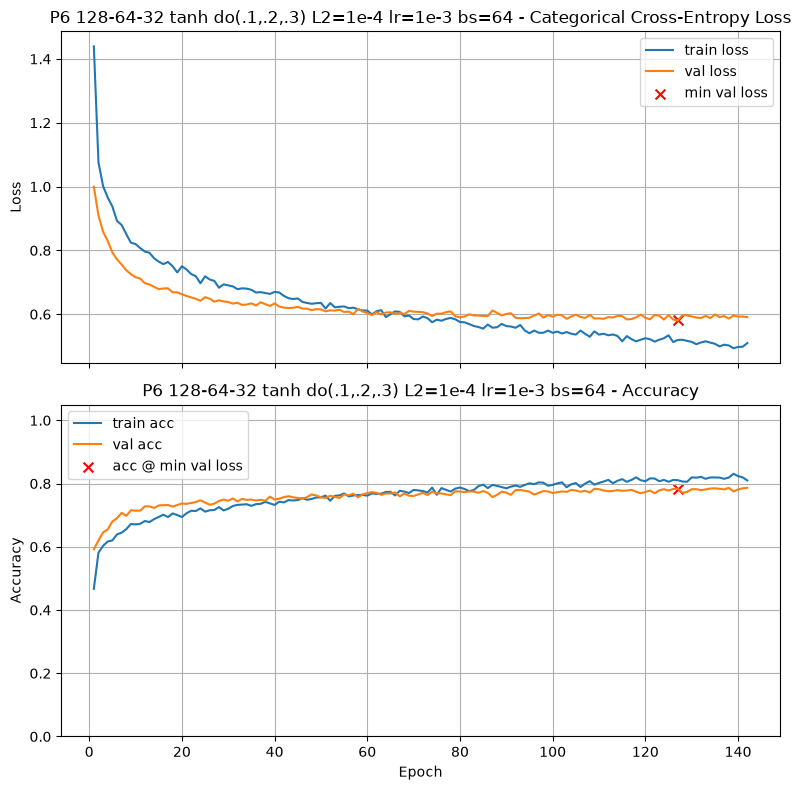

Final Training Loss:            0.5097
Final Training Accuracy:        0.8098
Final Validation Loss:          0.5908
Final Validation Accuracy:      0.7864
Minimum Validation Loss:        0.5805 (Epoch 127)
Validation Accuracy @ Min Loss: 0.7836

Test Loss: 0.5967
Test Accuracy: 0.7771

Validation-Test Gap (accuracy): 0.006429

Execution Time: 00:00:14

P6 256-128-64 relu do(.1,.2,.3) L2=1e-4 exp0.95 bs=64



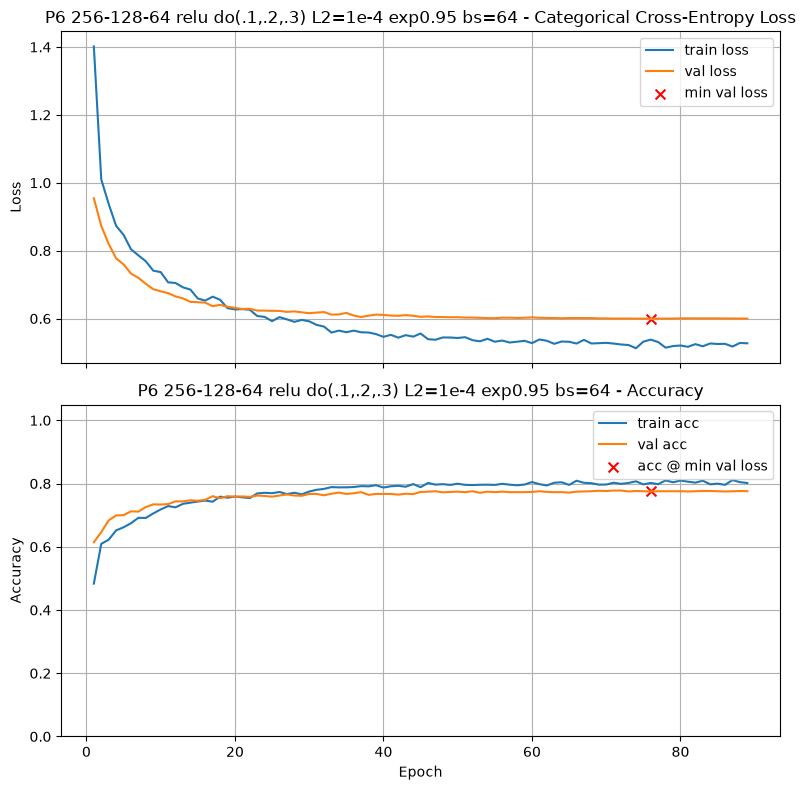

Final Training Loss:            0.5271
Final Training Accuracy:        0.8017
Final Validation Loss:          0.5998
Final Validation Accuracy:      0.7757
Minimum Validation Loss:        0.5997 (Epoch 76)
Validation Accuracy @ Min Loss: 0.7750

Test Loss: 0.6170
Test Accuracy: 0.7600

Validation-Test Gap (accuracy): 0.016429

Execution Time: 00:00:10

P6 256-128-64 relu do(.1,.2,.3) L2=1e-4 exp0.95 bs=32



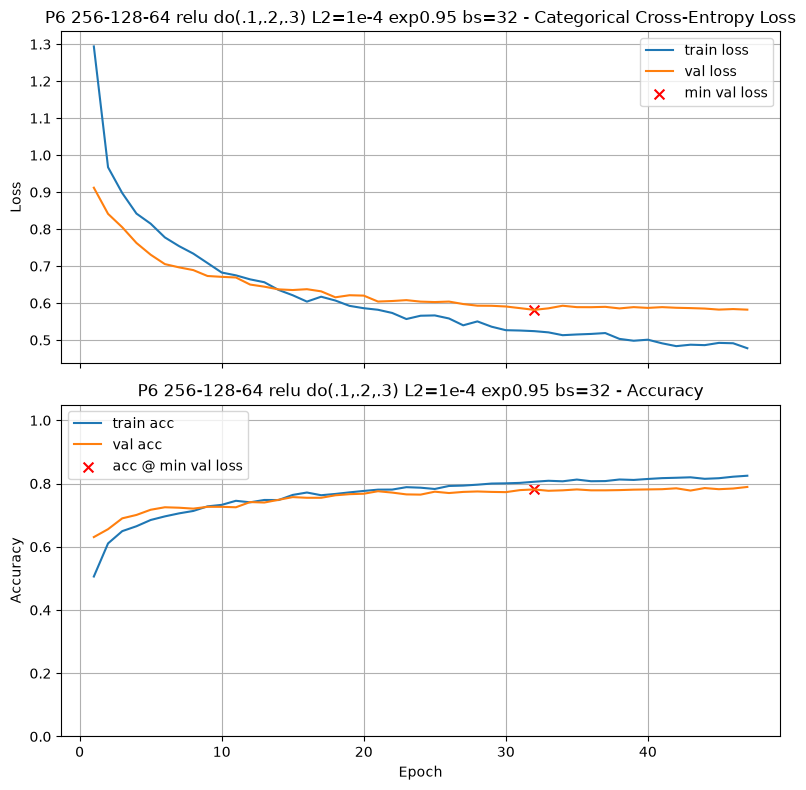

Final Training Loss:            0.4780
Final Training Accuracy:        0.8248
Final Validation Loss:          0.5823
Final Validation Accuracy:      0.7893
Minimum Validation Loss:        0.5817 (Epoch 32)
Validation Accuracy @ Min Loss: 0.7814

Test Loss: 0.6142
Test Accuracy: 0.7571

Validation-Test Gap (accuracy): 0.024286

Execution Time: 00:00:08

P6 256-128-64 relu do(0,.1,.2) L2=1e-4 exp0.97 bs=64



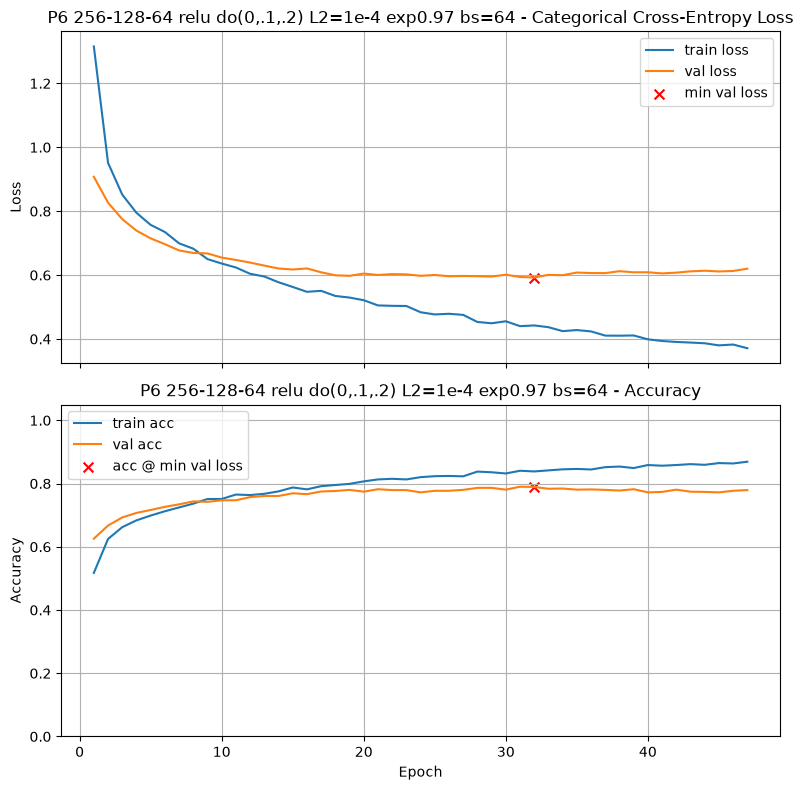

Final Training Loss:            0.3712
Final Training Accuracy:        0.8690
Final Validation Loss:          0.6201
Final Validation Accuracy:      0.7793
Minimum Validation Loss:        0.5925 (Epoch 32)
Validation Accuracy @ Min Loss: 0.7893

Test Loss: 0.6159
Test Accuracy: 0.7657

Validation-Test Gap (accuracy): 0.023571

Execution Time: 00:00:05

P6 256-128-64 relu do(0,.1,.2) L2=1e-4 exp0.97 bs=128



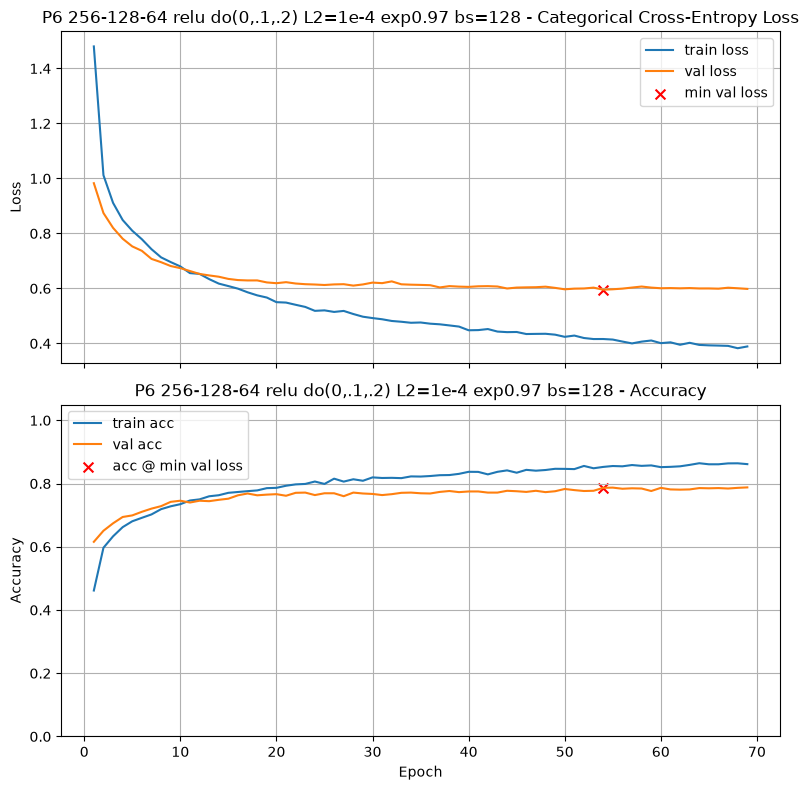

Final Training Loss:            0.3890
Final Training Accuracy:        0.8614
Final Validation Loss:          0.5983
Final Validation Accuracy:      0.7879
Minimum Validation Loss:        0.5955 (Epoch 54)
Validation Accuracy @ Min Loss: 0.7864

Test Loss: 0.6057
Test Accuracy: 0.7693

Validation-Test Gap (accuracy): 0.017143

Execution Time: 00:00:05

P6 512-256-128 relu do(0,.1,.2) L2=1e-4 exp0.97 bs=64



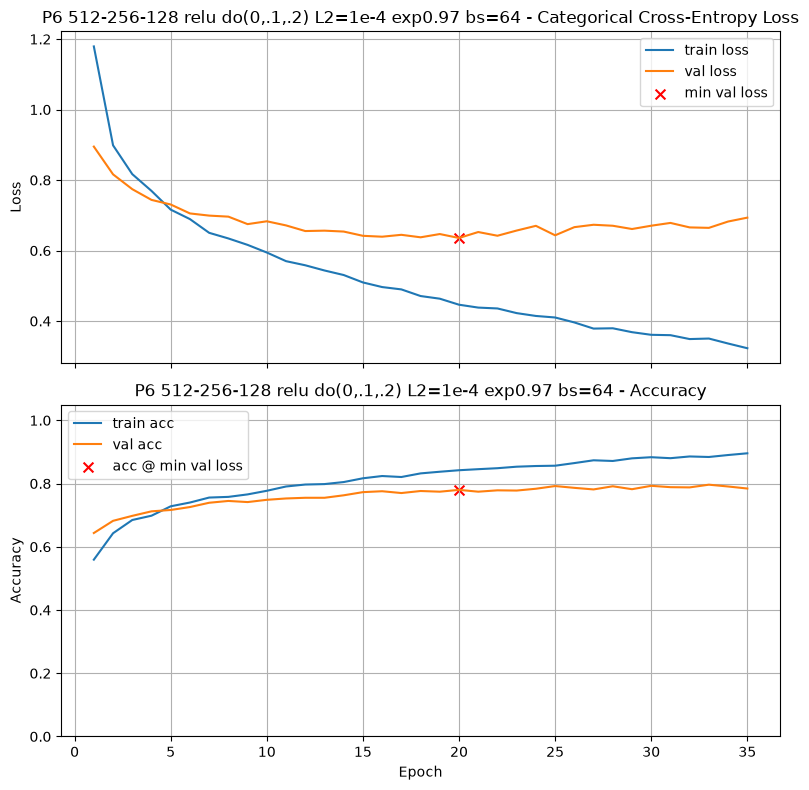

Final Training Loss:            0.3230
Final Training Accuracy:        0.8957
Final Validation Loss:          0.6935
Final Validation Accuracy:      0.7843
Minimum Validation Loss:        0.6358 (Epoch 20)
Validation Accuracy @ Min Loss: 0.7800

Test Loss: 0.6479
Test Accuracy: 0.7771

Validation-Test Gap (accuracy): 0.002857

Execution Time: 00:00:05

  P6 128-64-32 tanh do(.1,.2,.3) L2=1e-4 lr=1e-3 bs=64       0.7836   (best epoch 127)
  P6 256-128-64 relu do(.1,.2,.3) L2=1e-4 exp0.95 bs=64      0.7750   (best epoch 76)
  P6 256-128-64 relu do(.1,.2,.3) L2=1e-4 exp0.95 bs=32      0.7814   (best epoch 32)
  P6 256-128-64 relu do(0,.1,.2) L2=1e-4 exp0.97 bs=64       0.7893   (best epoch 32)
  P6 256-128-64 relu do(0,.1,.2) L2=1e-4 exp0.97 bs=128      0.7864   (best epoch 54)
  P6 512-256-128 relu do(0,.1,.2) L2=1e-4 exp0.97 bs=64      0.7800   (best epoch 20)

Best model: P6 256-128-64 relu do(0,.1,.2) L2=1e-4 exp0.97 bs=64  ->  0.7893


In [33]:
def exp_decay(lr0, rate, batch_size):
    steps_per_epoch = int(np.ceil(len(X_train) / batch_size))
    return ExponentialDecay(lr0, decay_steps=steps_per_epoch, decay_rate=rate, staircase=True)

p6_candidates = {
    "P6 128-64-32 tanh do(.1,.2,.3) L2=1e-4 lr=1e-3 bs=64":
        ([(128,'tanh',1e-4,0.1), (64,'tanh',1e-4,0.2), (32,'tanh',1e-4,0.3)], 1e-3, 64),
    "P6 256-128-64 relu do(.1,.2,.3) L2=1e-4 exp0.95 bs=64":
        ([(256,'relu',1e-4,0.1), (128,'relu',1e-4,0.2), (64,'relu',1e-4,0.3)], exp_decay(1e-3, 0.95, 64), 64),
    "P6 256-128-64 relu do(.1,.2,.3) L2=1e-4 exp0.95 bs=32":
        ([(256,'relu',1e-4,0.1), (128,'relu',1e-4,0.2), (64,'relu',1e-4,0.3)], exp_decay(1e-3, 0.95, 32), 32),
    "P6 256-128-64 relu do(0,.1,.2) L2=1e-4 exp0.97 bs=64":
        ([(256,'relu',1e-4,0.0), (128,'relu',1e-4,0.1), (64,'relu',1e-4,0.2)], exp_decay(1e-3, 0.97, 64), 64),
    "P6 256-128-64 relu do(0,.1,.2) L2=1e-4 exp0.97 bs=128":
        ([(256,'relu',1e-4,0.0), (128,'relu',1e-4,0.1), (64,'relu',1e-4,0.2)], exp_decay(1e-3, 0.97, 128), 128),
    "P6 512-256-128 relu do(0,.1,.2) L2=1e-4 exp0.97 bs=64":
        ([(512,'relu',1e-4,0.0), (256,'relu',1e-4,0.1), (128,'relu',1e-4,0.2)], exp_decay(1e-3, 0.97, 64), 64),
}

p6_results = {}
for title, (layer_list, lr, bs) in p6_candidates.items():
    p6_results[title] = run_experiment(layer_list, lr=lr, title=title, batch_size=bs, patience=15)

print()
for title, (acc, ep) in p6_results.items():
    print(f"  {title:<58} {acc:.4f}   (best epoch {ep})")

best_model_title = max(p6_results, key=lambda k: p6_results[k][0])
print(f"\nBest model: {best_model_title}  ->  {p6_results[best_model_title][0]:.4f}")

In [34]:
# Set a6 to the validation accuracy found by this best model

a6 = 0.7893             # Replace 0.0 with your answer

In [35]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a6 = {a6:.4f}') 

a6 = 0.7893


### Optional: Print out your results of all experiments

In [36]:
print_results()

P6 256-128-64 relu do(0,.1,.2) L2=1e-4 exp0.97 bs=64	0.7893
P6 256-128-64 relu do(0,.1,.2) L2=1e-4 exp0.97 bs=128	0.7864
P6 128-64-32 tanh do(.1,.2,.3) L2=1e-4 lr=1e-3 bs=64	0.7836
P6 256-128-64 relu do(.1,.2,.3) L2=1e-4 exp0.95 bs=32	0.7814
P6 512-256-128 relu do(0,.1,.2) L2=1e-4 exp0.97 bs=64	0.7800
P4 L2=(0.0001,0.0001)                   	0.7793
P2 lr=0.0001                            	0.7779
P2 lr=0.0005                            	0.7771
P4 L2=(0.001,0.0001)                    	0.7764
P6 256-128-64 relu do(.1,.2,.3) L2=1e-4 exp0.95 bs=64	0.7750
P1 baseline tanh                        	0.7729
P2 lr=0.001                             	0.7729
P4 L2=(0.001,0.001)                     	0.7721
P4 L2=(0.0001,0.001)                    	0.7721
P1 baseline sigmoid                     	0.7664
P1 baseline relu                        	0.7621
P5 dropout=(0.0,0.4) L2=0.001           	0.7614
P5 dropout=(0.0,0.4) L2=0.0001          	0.7600
P5 dropout=(0.0,0.3) L2=0.0001          	0.7586
P3 dropout=(

## Reflection Questions (ungraded)

It would be a great idea to think through your answers to these questions, then give ChatGPT (or other AI tool) a PDF of your
homework, and **discuss** (not just ask) these. 

1. Activation Functions:

    - Why do you think one activation function worked better than the others for this task?
    
    - How might this choice differ for deeper or wider networks?

2. Learning Rate:

    - Would a much smaller learning rate (with many more epochs) likely produce better accuracy?
    
    - When is it worth training longer with a smaller step size, and when is it unnecessary?

3. Dropout vs. L2:

    - Which form of regularization — dropout or L2 — gave better results in your experiments?
    
    - Why might one method be more effective in this setting?

4. Combining Dropout and L2:

    - Why might the combination of dropout and L2 sometimes perform worse than using one method alone?
    
    - What does this tell you about the balance between bias and variance in regularization?

5. Best Model:

    - When you designed your best model, what trade-offs did you notice between model complexity, training stability, and generalization?
    
    - Did learning rate scheduling (if you tried it) improve results? Why might it help?